In [1]:
# CELL 1: Imports et chargement des données

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Style des graphiques
sns.set_theme(style="whitegrid")
# Affichage des tableaux : toutes les colonnes, sur une largeur de 200 caractères, textes complets
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
pd.set_option('display.max_colwidth', None)

df = pd.read_csv('../data/raw/weatherAUS.csv')
print(f"Dataset chargé: {df.shape[0]} lignes × {df.shape[1]} colonnes")

Dataset chargé: 145460 lignes × 23 colonnes


Pourcentage de valeurs manquantes par colonne (%):
         Variable  Pourcentage
0        Sunshine        48.01
1     Evaporation        43.17
2        Cloud3pm        40.81
3        Cloud9am        38.42
4     Pressure9am        10.36
5     Pressure3pm        10.33
6      WindDir9am         7.26
7     WindGustDir         7.10
8   WindGustSpeed         7.06
9     Humidity3pm         3.10
10     WindDir3pm         2.91
11        Temp3pm         2.48
12   RainTomorrow         2.25
13       Rainfall         2.24
14      RainToday         2.24
15   WindSpeed3pm         2.11
16    Humidity9am         1.82
17   WindSpeed9am         1.21
18        Temp9am         1.21
19        MinTemp         1.02
20        MaxTemp         0.87
21           Date         0.00
22       Location         0.00



Figure sauvegardée: figures/etape2_01_valeurs_manquantes.png


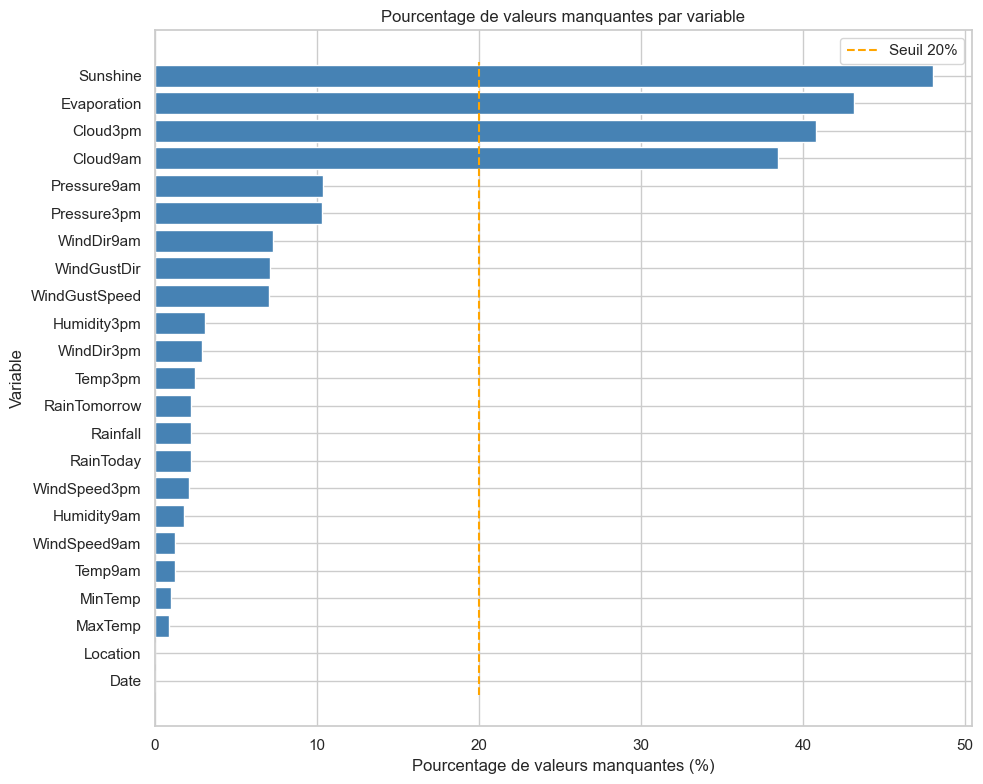

In [2]:
# CELL 2: État des lieux des valeurs manquantes

# Pourcentage de valeurs manquantes par colonne, trié décroissant
pct_manquant = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

# Tableau arrondi à 2 décimales pour l'affichage
pct_arrondis = []
for v in pct_manquant.values:
    pct_arrondis.append(round(v, 2))
table_manquant = pd.DataFrame({'Variable': pct_manquant.index, 'Pourcentage': pct_arrondis})
print("Pourcentage de valeurs manquantes par colonne (%):")
print(table_manquant)

# Graphique en barres horizontales (trié pour lecture, plus grand en haut)
pct_plot = pct_manquant.sort_values(ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(pct_plot.index, pct_plot.values, color='steelblue')
# Ligne de référence du seuil de 20%
plt.plot([20, 20], [-0.5, len(pct_plot) - 0.5], color='orange', linestyle='--', linewidth=1.5, label='Seuil 20%')
plt.title("Pourcentage de valeurs manquantes par variable")
plt.xlabel("Pourcentage de valeurs manquantes (%)")
plt.ylabel("Variable")
plt.legend()
plt.tight_layout()
plt.savefig('../figures/etape2_01_valeurs_manquantes.png', dpi=150)
print("\nFigure sauvegardée: figures/etape2_01_valeurs_manquantes.png")
plt.show()

In [3]:
# CELL 3: Suppression des variables très lacunaires (Sunshine, Evaporation, Cloud3pm, Cloud9am)

# Décision issue de la mesure en CELL 2 : ces 4 colonnes dépassent le seuil de 20% de valeurs manquantes (seuil recommandé pour supprimer une variable trop lacunaire)
print(f"Avant suppression des colonnes: {df.shape[0]} lignes × {df.shape[1]} colonnes")

colonnes_a_supprimer = ['Sunshine', 'Evaporation', 'Cloud3pm', 'Cloud9am']
df = df.drop(columns=colonnes_a_supprimer)

print(f"Après suppression des colonnes: {df.shape[0]} lignes × {df.shape[1]} colonnes")
print(f"Colonnes supprimées: {colonnes_a_supprimer}")

Avant suppression des colonnes: 145460 lignes × 23 colonnes
Après suppression des colonnes: 145460 lignes × 19 colonnes
Colonnes supprimées: ['Sunshine', 'Evaporation', 'Cloud3pm', 'Cloud9am']


In [4]:
# CELL 4: Construction de la cible à J+2 (RainInTwoDays)

import datetime as dt

# On travaille sur df tel qu'il est après CELL 3 (toutes les lignes, y compris celles sans RainTomorrow),
# pour que le RainToday de la ligne J+2 reste disponible même si cette ligne n'a pas de RainTomorrow
df['Date'] = pd.to_datetime(df['Date'])
nb_lignes_avant = df.shape[0]

# Table de correspondance (Location, Date, RainToday)
table_j2 = df[['Location', 'Date', 'RainToday']].copy()

# On recule la date de 2 jours : la ligne datée J+2 devient la clé de la ligne J
table_j2['Date'] = table_j2['Date'] - dt.timedelta(days=2)
table_j2 = table_j2.rename(columns={'RainToday': 'RainInTwoDays'})

# Fusion à gauche sur la station et la date : chaque ligne J reçoit le RainToday de la ligne J+2
# Si la ligne J+2 n'existe pas ou si son RainToday est manquant, RainInTwoDays reste manquant (jamais imputé)
df = df.merge(table_j2, on=['Location', 'Date'], how='left')

# Contrôle : la fusion ne doit pas dupliquer de lignes (couple Location, Date unique)
assert df.shape[0] == nb_lignes_avant

nb_j2_nan = df['RainInTwoDays'].isnull().sum()
print(f"Nombre de lignes: {df.shape[0]}")
print(f"Lignes avec RainInTwoDays manquant: {nb_j2_nan} ({nb_j2_nan / len(df) * 100:.2f}%)")

Nombre de lignes: 145460
Lignes avec RainInTwoDays manquant: 3629 (2.49%)


In [5]:
# CELL 5: Validation de la méthode sur un cas connu (J+1)

# Même méthode de fusion avec un décalage de 1 jour : le RainToday de la ligne J+1 doit égaler RainTomorrow
table_j1 = df[['Location', 'Date', 'RainToday']].copy()
table_j1['Date'] = table_j1['Date'] - dt.timedelta(days=1)
table_j1 = table_j1.rename(columns={'RainToday': 'RainTodayJ1'})
df = df.merge(table_j1, on=['Location', 'Date'], how='left')

# Comparaison sur les lignes où les deux valeurs sont présentes
comparables = df.dropna(subset=['RainTomorrow', 'RainTodayJ1'])
nb_egaux = (comparables['RainTomorrow'] == comparables['RainTodayJ1']).sum()
print(f"Lignes comparées (RainTomorrow et RainTodayJ1 présents): {len(comparables)}")
print(f"Concordances: {nb_egaux}")
print(f"Taux de concordance: {nb_egaux / len(comparables) * 100:.2f}%")

# Exemples J+1 pour vérification visuelle
print("\nExemples J+1:")
print(comparables[['Location', 'Date', 'RainTomorrow', 'RainTodayJ1']].sample(5, random_state=42))

# Exemples J+2 : on va chercher directement dans df la ligne datée J+2 de la même station
exemples_j2 = df.dropna(subset=['RainInTwoDays']).sample(5, random_state=42)
lignes_exemples = []
for i in range(len(exemples_j2)):
    ligne = exemples_j2.iloc[i]
    date_j2 = ligne['Date'] + dt.timedelta(days=2)
    ligne_j2 = df[(df['Location'] == ligne['Location']) & (df['Date'] == date_j2)].iloc[0]
    lignes_exemples.append({
        'Location': ligne['Location'],
        'Date': ligne['Date'],
        'RainInTwoDays': ligne['RainInTwoDays'],
        'Date_J2': ligne_j2['Date'],
        'RainToday_J2': ligne_j2['RainToday']
    })
print("\nExemples J+2 (ligne J+2 relue directement dans df):")
print(pd.DataFrame(lignes_exemples))

# Suppression de la colonne de contrôle
df = df.drop(columns=['RainTodayJ1'])

Lignes comparées (RainTomorrow et RainTodayJ1 présents): 142017
Concordances: 142017
Taux de concordance: 100.00%

Exemples J+1:
            Location       Date RainTomorrow RainTodayJ1
73557           Nhil 2013-08-03          Yes         Yes
119200  PerthAirport 2013-07-19           No          No
42295    Williamtown 2016-10-17          Yes         Yes
77749       Portland 2016-10-29           No          No
104332     Nuriootpa 2014-02-12          Yes         Yes



Exemples J+2 (ligne J+2 relue directement dans df):
       Location       Date RainInTwoDays    Date_J2 RainToday_J2
0  PerthAirport 2016-10-06           Yes 2016-10-08          Yes
1   Witchcliffe 2015-09-08           Yes 2015-09-10          Yes
2      Portland 2011-10-08           Yes 2011-10-10          Yes
3         Moree 2016-12-17            No 2016-12-19           No
4         Cobar 2009-05-17           Yes 2009-05-19          Yes


In [6]:
# CELL 6: Suppression des lignes sans variable cible (RainTomorrow manquante)

# La cible RainTomorrow ne peut pas être imputée : on retire les lignes où elle est manquante
nb_lignes_avant = df.shape[0]
nb_cible_nan = df['RainTomorrow'].isnull().sum()
print(f"Nombre de lignes avant: {nb_lignes_avant}")
print(f"Nombre de RainTomorrow manquants: {nb_cible_nan}")

df = df.dropna(subset=['RainTomorrow'])

print(f"Après suppression des lignes sans cible: {df.shape[0]} lignes × {df.shape[1]} colonnes")
print(f"Nombre de lignes supprimées: {nb_lignes_avant - df.shape[0]}")

# Cible à J+2 sur les lignes restantes (valeurs manquantes conservées pour l'instant)
nb_j2_nan = df['RainInTwoDays'].isnull().sum()
print(f"Lignes restantes avec RainInTwoDays manquant: {nb_j2_nan} ({nb_j2_nan / len(df) * 100:.2f}%)")

Nombre de lignes avant: 145460
Nombre de RainTomorrow manquants: 3267


Après suppression des lignes sans cible: 142193 lignes × 20 colonnes
Nombre de lignes supprimées: 3267
Lignes restantes avec RainInTwoDays manquant: 1762 (1.24%)


In [7]:
# CELL 7: Découpage temporel train/test (les dates les plus anciennes en entraînement, les plus récentes en test)

# Tri chronologique
df = df.sort_values('Date').reset_index().drop(columns=['index'])

# Date de coupure : date située au 80e percentile de la colonne Date triée
date_coupure = df['Date'].iloc[int(len(df) * 0.80)]

# Toutes les stations d'un même jour restent du même côté du découpage
masque_train = df['Date'] < date_coupure
df_train = df[masque_train]
df_test = df[masque_train == False]

# Variables explicatives (Location et Date conservées pour l'instant) et les deux cibles
colonnes_cibles = ['RainTomorrow', 'RainInTwoDays']
X_train = df_train.drop(columns=colonnes_cibles)
X_test = df_test.drop(columns=colonnes_cibles)
y_train = df_train['RainTomorrow']
y_test = df_test['RainTomorrow']
y2_train = df_train['RainInTwoDays']
y2_test = df_test['RainInTwoDays']

# Informations de station et de date pour l'analyse par station plus tard
meta_train = df_train[['Location', 'Date']]
meta_test = df_test[['Location', 'Date']]

# Les dates sont affichées avec leurs 10 premiers caractères (AAAA-MM-JJ)
print(f"Date de coupure: {str(date_coupure)[:10]}")
print(f"Entraînement: du {str(X_train['Date'].min())[:10]} au {str(X_train['Date'].max())[:10]}")
print(f"Test:         du {str(X_test['Date'].min())[:10]} au {str(X_test['Date'].max())[:10]}")
print(f"\nX_train: {X_train.shape[0]} lignes × {X_train.shape[1]} colonnes ({len(X_train) / len(df) * 100:.2f}%)")
print(f"X_test:  {X_test.shape[0]} lignes × {X_test.shape[1]} colonnes ({len(X_test) / len(df) * 100:.2f}%)")
print(f"\nLocalités distinctes en entraînement: {X_train['Location'].nunique()}")
print(f"Localités distinctes en test: {X_test['Location'].nunique()}")

print(f"\nRainTomorrow = Yes en entraînement: {(y_train == 'Yes').mean() * 100:.2f}%")
print(f"RainTomorrow = Yes en test: {(y_test == 'Yes').mean() * 100:.2f}%")
print(f"\nRainInTwoDays = Yes en entraînement (valeurs non manquantes): {(y2_train.dropna() == 'Yes').mean() * 100:.2f}%")
print(f"RainInTwoDays = Yes en test (valeurs non manquantes): {(y2_test.dropna() == 'Yes').mean() * 100:.2f}%")

Date de coupure: 2015-11-10
Entraînement: du 2007-11-01 au 2015-11-09
Test:         du 2015-11-10 au 2017-06-25

X_train: 113748 lignes × 18 colonnes (80.00%)
X_test:  28445 lignes × 18 colonnes (20.00%)

Localités distinctes en entraînement: 49
Localités distinctes en test: 49

RainTomorrow = Yes en entraînement: 22.44%


RainTomorrow = Yes en test: 22.32%

RainInTwoDays = Yes en entraînement (valeurs non manquantes): 22.18%
RainInTwoDays = Yes en test (valeurs non manquantes): 22.10%


Figure sauvegardée: figures/etape2_02_decoupage_temporel.png


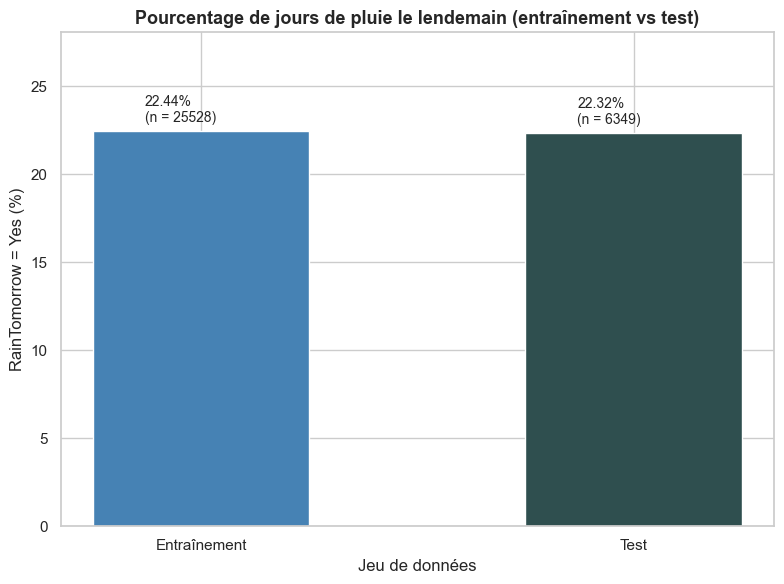

In [8]:
# CELL 8: Vérification visuelle du découpage temporel

# Pourcentage et nombre de jours de pluie le lendemain (RainTomorrow = Yes) dans chaque jeu
jeux = ['Entraînement', 'Test']
pourcentages = [(y_train == 'Yes').mean() * 100, (y_test == 'Yes').mean() * 100]
effectifs = [(y_train == 'Yes').sum(), (y_test == 'Yes').sum()]

plt.figure(figsize=(8, 6))
plt.bar(jeux, pourcentages, width=0.5, color=['steelblue', 'darkslategray'])

# Valeur et effectif au-dessus de chaque barre (texte décalé vers la gauche pour rester centré sur la barre)
plt.text(-0.13, pourcentages[0] + 0.5, f"{pourcentages[0]:.2f}%\n(n = {effectifs[0]})", fontsize=10)
plt.text(0.87, pourcentages[1] + 0.5, f"{pourcentages[1]:.2f}%\n(n = {effectifs[1]})", fontsize=10)

plt.title("Pourcentage de jours de pluie le lendemain (entraînement vs test)",
          fontsize=13, fontweight='bold')
plt.xlabel("Jeu de données")
plt.ylabel("RainTomorrow = Yes (%)")
plt.ylim(0, max(pourcentages) * 1.25)
plt.tight_layout()
plt.savefig('../figures/etape2_02_decoupage_temporel.png', dpi=150)
print("Figure sauvegardée: figures/etape2_02_decoupage_temporel.png")
plt.show()

In [9]:
# CELL 9: Copie des données d'entraînement avant imputation (pour les comparaisons)

# Copie intacte de X_train (avec Location et Date) et des cibles brutes, avant toute imputation :
# les deux comparaisons (imputation globale / locale, sélection de variables) travaillent à partir de cette copie
X_train_avant_imputation = X_train.copy()
y_train_avant_imputation = y_train.copy()
y2_train_avant_imputation = y2_train.copy()

print(f"X_train_avant_imputation: {X_train_avant_imputation.shape[0]} lignes × {X_train_avant_imputation.shape[1]} colonnes")
print(f"Valeurs manquantes conservées: {int(X_train_avant_imputation.isnull().sum().sum())}")
print(f"Colonnes: {list(X_train_avant_imputation.columns)}")

X_train_avant_imputation: 113748 lignes × 18 colonnes
Valeurs manquantes conservées: 58845
Colonnes: ['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Temp9am', 'Temp3pm', 'RainToday']


In [10]:
# CELL 10: Détection des valeurs aberrantes par la méthode IQR (sur X_train)

# Mesure faite sur X_train uniquement (pas de fuite depuis le test), colonnes numériques
X_train_num = X_train.select_dtypes(include=['int', 'float'])
print(f"Colonnes numériques utilisées ({len(X_train_num.columns)}): {list(X_train_num.columns)}\n")

resultats_iqr = []
for col in X_train_num.columns:
    Q1 = X_train_num[col].quantile(0.25)
    Q3 = X_train_num[col].quantile(0.75)
    IQR = Q3 - Q1
    borne_inf = Q1 - 1.5 * IQR
    borne_sup = Q3 + 1.5 * IQR
    # Une valeur manquante n'est pas comptée comme aberrante (comparaison -> False)
    masque_outliers = (X_train_num[col] < borne_inf) | (X_train_num[col] > borne_sup)
    nb_outliers = int(masque_outliers.sum())
    # Pourcentage rapporté aux valeurs non manquantes de la variable
    nb_non_nuls = (X_train_num[col].isnull() == False).sum()
    pct_outliers = nb_outliers / nb_non_nuls * 100
    resultats_iqr.append({
        'Variable': col, 'Q1': Q1, 'Q3': Q3,
        'borne_inf': borne_inf, 'borne_sup': borne_sup,
        'nb_outliers': nb_outliers, 'pct_outliers': pct_outliers,
        # Valeurs réelles de X_train, valeurs manquantes exclues
        'min': X_train_num[col].min(), 'max': X_train_num[col].max()
    })

table_iqr = pd.DataFrame(resultats_iqr).sort_values('pct_outliers', ascending=False).reset_index().drop(columns=['index'])

# Arrondi à 2 décimales pour la lisibilité de l'affichage (après le tri)
for c in ['Q1', 'Q3', 'borne_inf', 'borne_sup', 'pct_outliers', 'min', 'max']:
    valeurs_arrondies = []
    for v in table_iqr[c].values:
        valeurs_arrondies.append(round(v, 2))
    table_iqr[c] = valeurs_arrondies

print("Détection des valeurs aberrantes (méthode IQR, X_train):")
print(table_iqr)

Colonnes numériques utilisées (12): ['MinTemp', 'MaxTemp', 'Rainfall', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Temp9am', 'Temp3pm']

Détection des valeurs aberrantes (méthode IQR, X_train):
         Variable      Q1      Q3  borne_inf  borne_sup  nb_outliers  pct_outliers    min     max
0        Rainfall     0.0     0.8      -1.20       2.00        20188         17.93    0.0   371.0
1   WindGustSpeed    31.0    48.0       5.50      73.50         2432          2.29    6.0   135.0
2    WindSpeed3pm    13.0    24.0      -3.50      40.50         1983          1.77    0.0    87.0
3    WindSpeed9am     7.0    19.0     -11.00      37.00         1446          1.28    0.0    87.0
4     Humidity9am    57.0    83.0      18.00     122.00         1193          1.06    0.0   100.0
5     Pressure9am  1013.1  1022.6     998.85    1036.85          893          0.87  980.5  1041.0
6     Pressure3pm  1010.6  1020.2     996.20    1034.6

Figure sauvegardée: figures/etape2_03_outliers_iqr.png


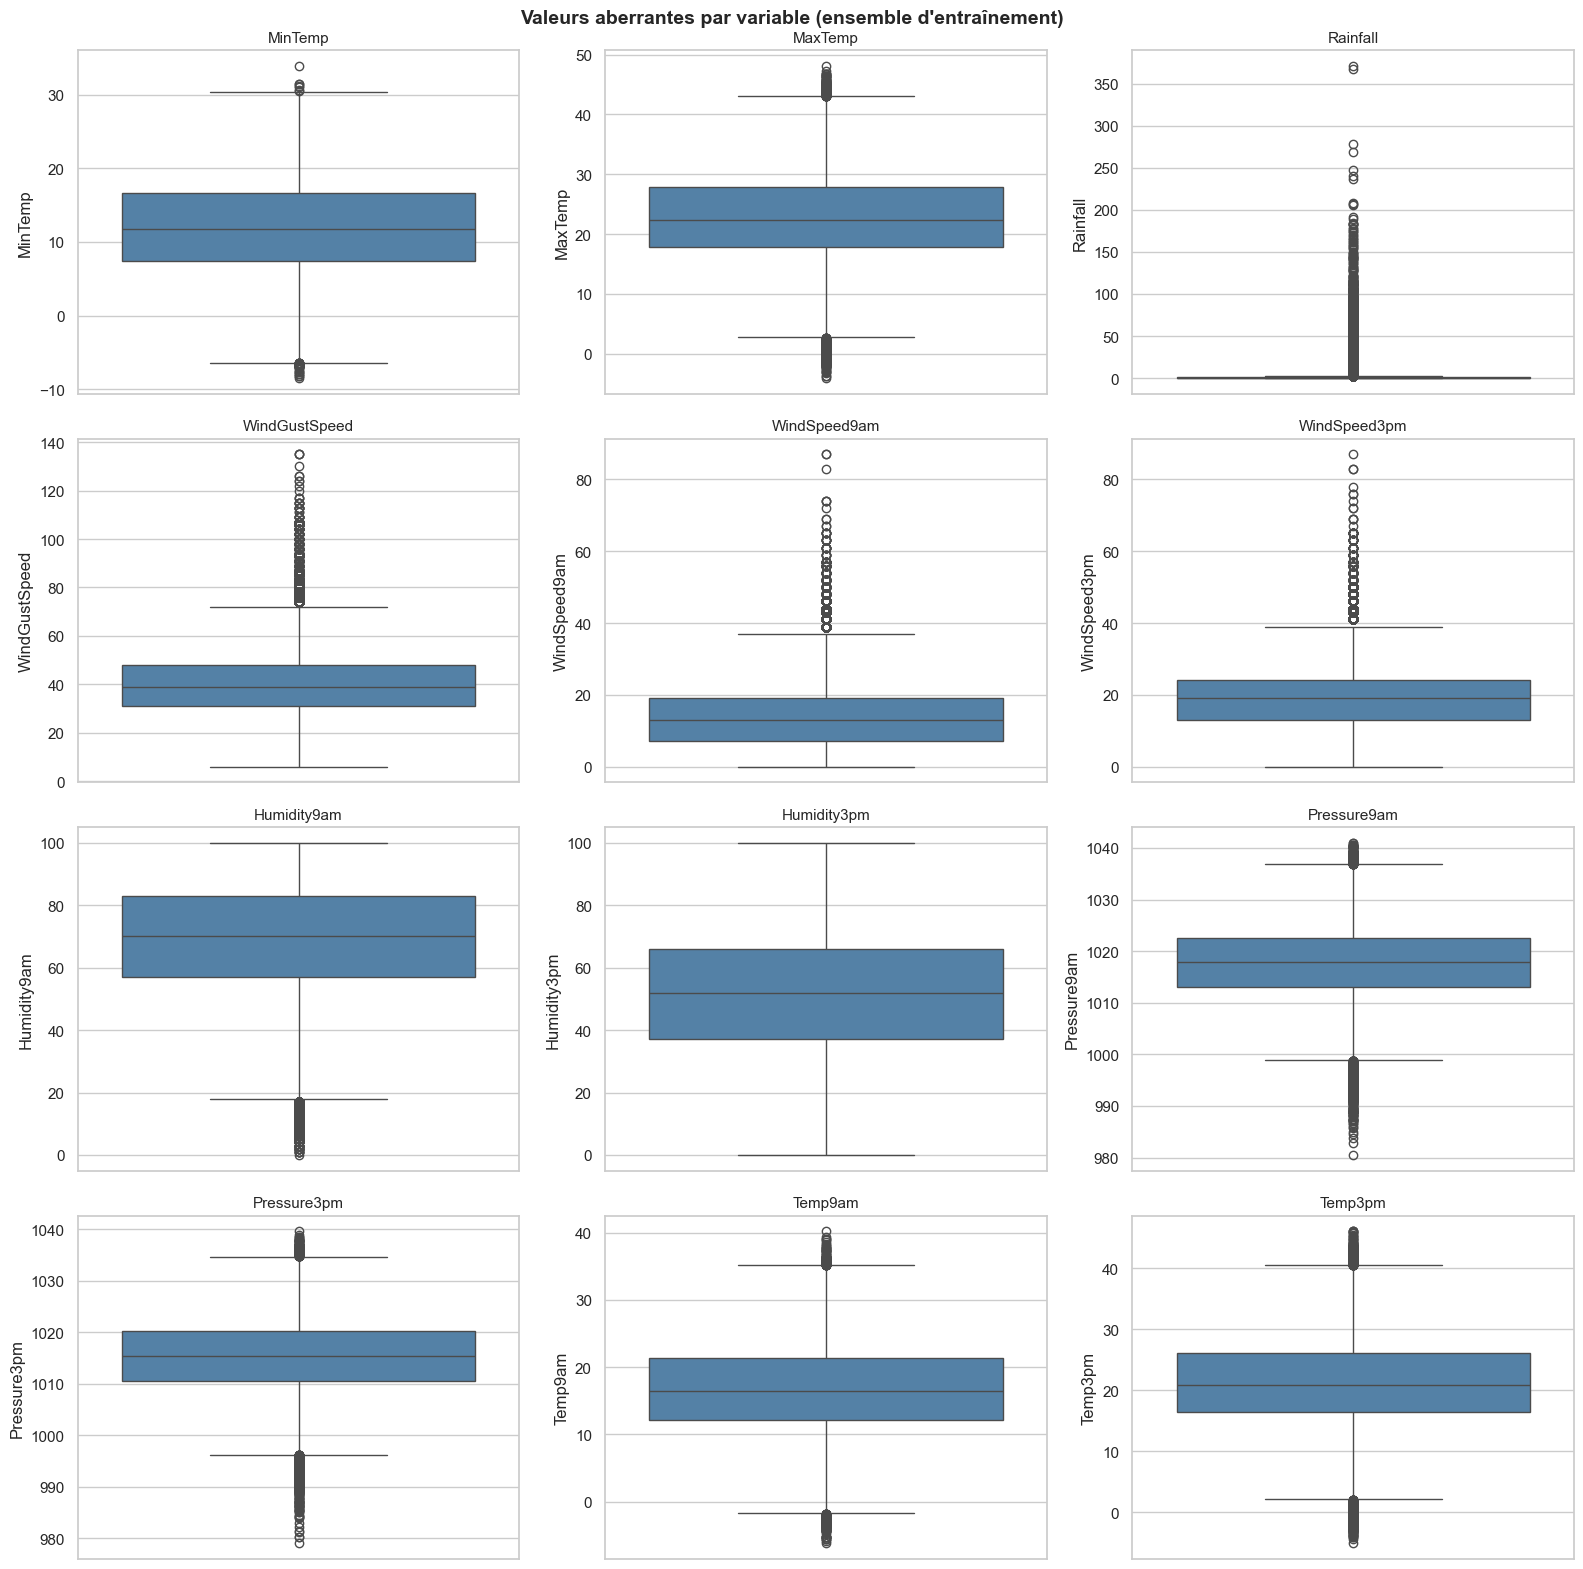

In [11]:
# CELL 11: Visualisation des valeurs aberrantes (boxplots, X_train)

# Un sous-graphique par variable : chaque variable garde sa propre échelle
# (les échelles sont très différentes : pression ~1000, humidité ~50, rainfall asymétrique)
colonnes_num = X_train_num.columns
n = len(colonnes_num)
n_cols = 3
# Nombre de lignes de la grille : division entière arrondie au supérieur
n_rows = (n + n_cols - 1) // n_cols

plt.figure(figsize=(16, 4 * n_rows))

for i in range(n):
    col = colonnes_num[i]
    plt.subplot(n_rows, n_cols, i + 1)
    sns.boxplot(y=X_train_num[col], color='steelblue')
    plt.title(col, fontsize=11)
    plt.ylabel(col)

plt.suptitle("Valeurs aberrantes par variable (ensemble d'entraînement)",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/etape2_03_outliers_iqr.png', dpi=150)
print("Figure sauvegardée: figures/etape2_03_outliers_iqr.png")
plt.show()

In [12]:
# CELL 12: Mesure de l'asymétrie des variables numériques (X_train)

# Mesure sur X_train uniquement (règle anti-fuite), colonnes numériques
X_train_num = X_train.select_dtypes(include=['int', 'float'])

resultats_skew = []
for col in X_train_num.columns:
    skew = X_train_num[col].skew()
    # Seuil conventionnel : une asymétrie |skew| >= 0.5 est considérée comme marquée -> médiane (robuste aux valeurs extrêmes), sinon moyenne
    regle = 'moyenne'
    if np.abs(skew) >= 0.5:
        regle = 'mediane'
    nb_manquants = int(X_train[col].isnull().sum())
    resultats_skew.append({
        'Variable': col,
        'skewness': round(skew, 3),
        'règle_imputation': regle,
        'nb_manquants': nb_manquants
    })

table_skew = pd.DataFrame(resultats_skew)
# Tri par asymétrie absolue décroissante : colonne de la valeur absolue, tri, puis suppression de la colonne
table_skew['abs_skewness'] = np.abs(table_skew['skewness'])
table_skew = table_skew.sort_values('abs_skewness', ascending=False).reset_index().drop(columns=['index'])
table_skew = table_skew.drop(columns=['abs_skewness'])

print("Asymétrie (skewness) des variables numériques (X_train):")
print(table_skew)

Asymétrie (skewness) des variables numériques (X_train):
         Variable  skewness règle_imputation  nb_manquants
0        Rainfall    10.126          mediane          1127
1   WindGustSpeed     0.870          mediane          7674
2    WindSpeed9am     0.763          mediane          1203
3    WindSpeed3pm     0.614          mediane          1400
4     Humidity9am    -0.488          moyenne          1476
5         Temp3pm     0.259          moyenne           986
6         MaxTemp     0.238          moyenne           223
7         Temp9am     0.099          moyenne           807
8     Pressure9am    -0.094          moyenne         11068
9     Pressure3pm    -0.047          moyenne         11033
10        MinTemp     0.031          moyenne           469
11    Humidity3pm     0.025          moyenne          1695


Figure sauvegardée: figures/etape2_04_distributions_numeriques.png


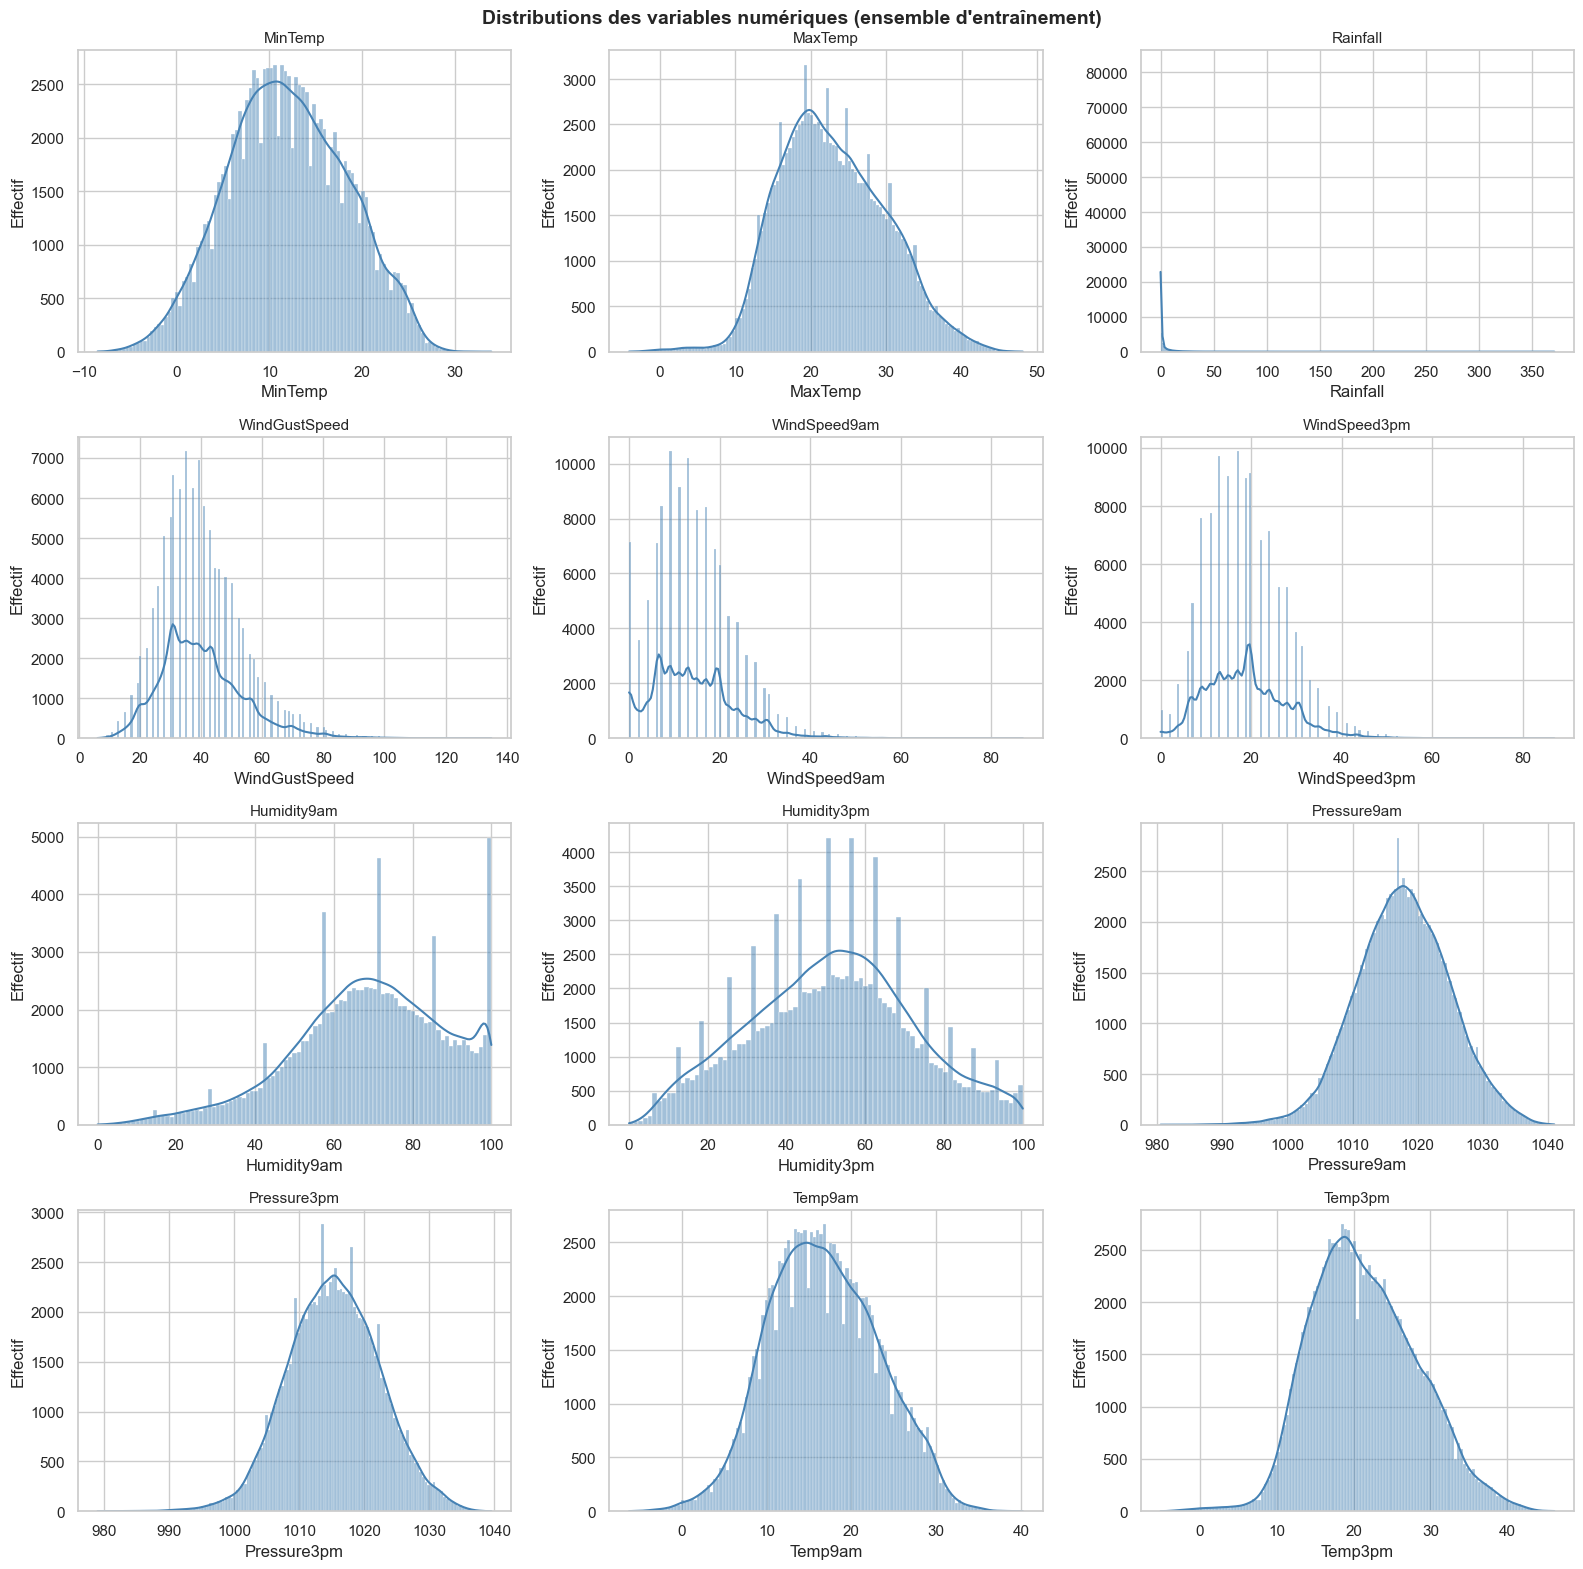

In [13]:
# CELL 13: Visualisation des distributions numériques (X_train)

# Un sous-graphique par variable : chaque variable garde sa propre échelle
colonnes_num = X_train_num.columns
n = len(colonnes_num)
n_cols = 3
# Nombre de lignes de la grille : division entière arrondie au supérieur
n_rows = (n + n_cols - 1) // n_cols

plt.figure(figsize=(16, 4 * n_rows))

for i in range(n):
    col = colonnes_num[i]
    plt.subplot(n_rows, n_cols, i + 1)
    sns.histplot(X_train[col].dropna(), kde=True, color='steelblue')
    plt.title(col, fontsize=11)
    plt.xlabel(col)
    plt.ylabel("Effectif")

plt.suptitle("Distributions des variables numériques (ensemble d'entraînement)",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/etape2_04_distributions_numeriques.png', dpi=150)
print("Figure sauvegardée: figures/etape2_04_distributions_numeriques.png")
plt.show()

In [14]:
# CELL 14: Paires de mesures 9h / 15h

# Pourquoi cette étape : quand une valeur d'une paire (Temp9am/Temp3pm, Humidity9am/Humidity3pm,
# Pressure9am/Pressure3pm) est manquante et l'autre mesurée, la remplir par une moyenne de station crée
# un écart 15h - 9h qui n'a jamais été mesuré (mesure en CELL 17).
# Les deux valeurs d'une paire sont fortement liées (mesure en CELL 15) : une valeur
# manquante est donc imputée à partir de la valeur mesurée le même jour et de l'écart typique 9h -> 15h.

# Paires 9h / 15h, repérées par le nom de l'écart correspondant
paires_diff = {
    'Temp_diff': ('Temp9am', 'Temp3pm'),
    'Humidity_diff': ('Humidity9am', 'Humidity3pm'),
    'Pressure_diff': ('Pressure9am', 'Pressure3pm')
}

In [15]:
# CELL 15: Mesure du lien entre les mesures de 9h et de 15h (X_train)

regle_ecart = {}
lignes_lien = []
for var_diff in paires_diff:
    col_9h = paires_diff[var_diff][0]
    col_15h = paires_diff[var_diff][1]
    manque_9h = X_train[col_9h].isnull()
    manque_15h = X_train[col_15h].isnull()
    # Paires complètes : aucune des deux valeurs n'est manquante
    completes = X_train[(manque_9h == False) & (manque_15h == False)]

    # Lien entre les deux mesures et forme de l'écart, sur les paires complètes uniquement
    correlation = completes[col_9h].corr(completes[col_15h])
    ecart = completes[col_15h] - completes[col_9h]
    skew = ecart.skew()
    # Même règle qu'en CELL 12 : |skew| >= 0.5 -> médiane, sinon moyenne
    regle = 'moyenne'
    if np.abs(skew) >= 0.5:
        regle = 'mediane'
    regle_ecart[var_diff] = regle

    lignes_lien.append({
        'Paire': f"{col_9h} / {col_15h}",
        'Pearson': round(correlation, 4),
        'skew_écart': round(skew, 3),
        'statistique_écart': regle,
        'deux_mesurées': int(((manque_9h == False) & (manque_15h == False)).sum()),
        # Exactement une valeur manquante : les deux indicateurs sont différents
        'une_manquante': int((manque_9h != manque_15h).sum()),
        'deux_manquantes': int((manque_9h & manque_15h).sum())
    })

table_lien = pd.DataFrame(lignes_lien)
print("Lien entre les mesures de 9h et de 15h (X_train, paires complètes pour Pearson et l'écart):")
print(table_lien)

Lien entre les mesures de 9h et de 15h (X_train, paires complètes pour Pearson et l'écart):
                       Paire  Pearson  skew_écart statistique_écart  deux_mesurées  une_manquante  deux_manquantes
0          Temp9am / Temp3pm   0.8598       0.303           moyenne         112219           1265              264
1  Humidity9am / Humidity3pm   0.6649       0.075           moyenne         111414           1497              837
2  Pressure9am / Pressure3pm   0.9619       0.609           mediane         102504            387            10857


In [16]:
# CELL 16: Bornes IQR des écarts mesurés (paires complètes, X_train)

# Bornes IQR et pourcentage de valeurs aberrantes des écarts mesurés (paires complètes, même méthode
# qu'en CELL 10), conservés pour la CELL 17, la CELL 45 et la CELL 73
bornes_ecarts_mesures = {}
pct_outliers_ecarts_mesures = {}
for var_diff in paires_diff:
    col_9h = paires_diff[var_diff][0]
    col_15h = paires_diff[var_diff][1]
    completes = X_train.dropna(subset=[col_9h, col_15h])
    ecart_mesure = completes[col_15h] - completes[col_9h]
    Q1 = ecart_mesure.quantile(0.25)
    Q3 = ecart_mesure.quantile(0.75)
    IQR = Q3 - Q1
    borne_inf = Q1 - 1.5 * IQR
    borne_sup = Q3 + 1.5 * IQR
    bornes_ecarts_mesures[var_diff] = (borne_inf, borne_sup)
    pct_outliers_ecarts_mesures[var_diff] = ((ecart_mesure < borne_inf) | (ecart_mesure > borne_sup)).mean() * 100

In [17]:
# CELL 17: Mesure du biais évité (justification de l'imputation selon le lien)

# Mesure uniquement : X_train et X_test ne sont pas modifiés
# Écart hypothétique : celui qu'on aurait obtenu en remplissant la valeur manquante par la moyenne
# de la station sur X_train (moyenne globale si la station n'a aucune valeur), puis en calculant l'écart
ecarts_hypothetiques = {}
for var_diff in paires_diff:
    col_9h = paires_diff[var_diff][0]
    col_15h = paires_diff[var_diff][1]
    borne_inf = bornes_ecarts_mesures[var_diff][0]
    borne_sup = bornes_ecarts_mesures[var_diff][1]

    # Lignes où exactement UNE des deux valeurs est manquante
    masque_une = X_train[col_9h].isnull() != X_train[col_15h].isnull()
    lignes = X_train[masque_une]

    # Remplissage hypothétique par la moyenne de la station (repli : moyenne globale de X_train)
    moyenne_station_9h = lignes['Location'].map(X_train.groupby('Location')[col_9h].mean())
    valeurs_9h = lignes[col_9h].fillna(moyenne_station_9h).fillna(X_train[col_9h].mean())
    moyenne_station_15h = lignes['Location'].map(X_train.groupby('Location')[col_15h].mean())
    valeurs_15h = lignes[col_15h].fillna(moyenne_station_15h).fillna(X_train[col_15h].mean())
    ecart_hyp = valeurs_15h - valeurs_9h
    ecarts_hypothetiques[var_diff] = ecart_hyp
    pct_hyp = ((ecart_hyp < borne_inf) | (ecart_hyp > borne_sup)).mean() * 100

    print(f"{var_diff} (bornes IQR des écarts mesurés: {borne_inf:.2f} / {borne_sup:.2f}):")
    print(f"  Lignes avec exactement une valeur manquante: {len(lignes)}")
    print(f"  Écarts hypothétiques hors bornes: {pct_hyp:.2f}% | "
          f"écarts mesurés hors bornes: {pct_outliers_ecarts_mesures[var_diff]:.2f}%")

Temp_diff (bornes IQR des écarts mesurés: -5.55 / 14.85):
  Lignes avec exactement une valeur manquante: 1265
  Écarts hypothétiques hors bornes: 6.64% | écarts mesurés hors bornes: 0.56%
Humidity_diff (bornes IQR des écarts mesurés: -61.00 / 27.00):
  Lignes avec exactement une valeur manquante: 1497
  Écarts hypothétiques hors bornes: 1.67% | écarts mesurés hors bornes: 1.01%
Pressure_diff (bornes IQR des écarts mesurés: -7.30 / 2.30):
  Lignes avec exactement une valeur manquante: 387
  Écarts hypothétiques hors bornes: 48.58% | écarts mesurés hors bornes: 2.66%


In [18]:
# CELL 18: Les 5 écarts hypothétiques de pression les plus extrêmes

# Plus grande valeur absolue de l'écart hypothétique de pression (CELL 17)
ecart_p = ecarts_hypothetiques['Pressure_diff']
top_5 = np.abs(ecart_p).sort_values(ascending=False).head(5).index
ecarts_top_5 = []
for v in ecart_p.loc[top_5].values:
    ecarts_top_5.append(round(v, 2))
table_top5 = pd.DataFrame({
    'Location': X_train.loc[top_5, 'Location'],
    'Date': X_train.loc[top_5, 'Date'],
    'Pressure9am': X_train.loc[top_5, 'Pressure9am'],
    'Pressure3pm': X_train.loc[top_5, 'Pressure3pm'],
    'Écart_hypothétique': ecarts_top_5
})
print("\nLes 5 écarts hypothétiques de pression les plus extrêmes (NaN = valeur manquante à l'origine):")
print(table_top5)


Les 5 écarts hypothétiques de pression les plus extrêmes (NaN = valeur manquante à l'origine):
        Location       Date  Pressure9am  Pressure3pm  Écart_hypothétique
46231       Sale 2011-09-29          NaN        991.1              -26.86
51773    Bendigo 2012-01-30          NaN        993.9              -24.31
10535  Nuriootpa 2009-06-30        994.9          NaN               22.12
76795  Nuriootpa 2013-09-23          NaN        999.8              -19.34
14319  NorahHead 2009-09-22          NaN        999.7              -18.74


In [19]:
# CELL 19: Listes de variables par statistique d'imputation

# Ordre standard : traitement des valeurs manquantes d'abord, création des nouvelles variables ensuite.
# Les paires 9h / 15h sont imputées selon leur lien (voir CELL 15 et CELL 17).

# Décisions d'imputation (règle |skew| >= 0.5 mesurée en CELL 12) :
# - médiane pour les variables asymétriques
# - moyenne pour les variables quasi-symétriques (Humidity9am : skew -0.488 -> moyenne)
# - mode pour les variables catégorielles
cols_mediane = ['Rainfall', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm']
cols_moyenne = ['MinTemp', 'MaxTemp', 'Temp9am', 'Temp3pm', 'Humidity9am', 'Humidity3pm',
                'Pressure9am', 'Pressure3pm']
cols_mode = ['WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday']

In [20]:
# CELL 20: Fonctions de calcul des statistiques d'imputation

def mode_ou_vide(serie):
    # Mode d'une série, ou None si la série ne contient aucune valeur non manquante
    m = serie.mode()
    if len(m) > 0:
        return m[0]
    return None


def calculer_stats_imputation(X_tr):
    # Statistiques calculées sur les valeurs mesurées de X_tr uniquement
    # stats_globales : une valeur par variable
    # stats_locales : une valeur par station pour chaque variable, manquante si la station n'a aucune valeur
    stats_globales = {}
    stats_locales = {}
    for col in cols_mediane:
        stats_globales[col] = X_tr[col].median()
        stats_locales[col] = X_tr.groupby('Location')[col].median()
    for col in cols_moyenne:
        stats_globales[col] = X_tr[col].mean()
        stats_locales[col] = X_tr.groupby('Location')[col].mean()
    for col in cols_mode:
        stats_globales[col] = X_tr[col].mode()[0]
        stats_locales[col] = X_tr.groupby('Location')[col].agg(mode_ou_vide)
    return stats_globales, stats_locales

In [21]:
# CELL 21: Fonction de calcul des écarts typiques 15h - 9h

def calculer_ecarts_types(X_tr):
    # Écart typique 15h - 9h de chaque paire, sur les paires complètes de X_tr uniquement
    # (statistique choisie en CELL 15) : une valeur globale et une valeur par Location
    # (manquante si la station n'a aucune paire complète)
    ecarts_globaux = {}
    ecarts_locaux = {}
    for var_diff in paires_diff:
        col_9h = paires_diff[var_diff][0]
        col_15h = paires_diff[var_diff][1]
        completes = X_tr.dropna(subset=[col_9h, col_15h])
        ecart = completes[col_15h] - completes[col_9h]
        if regle_ecart[var_diff] == 'mediane':
            ecarts_globaux[var_diff] = ecart.median()
            ecarts_locaux[var_diff] = ecart.groupby(completes['Location']).median()
        else:
            ecarts_globaux[var_diff] = ecart.mean()
            ecarts_locaux[var_diff] = ecart.groupby(completes['Location']).mean()
    return ecarts_globaux, ecarts_locaux

In [22]:
# CELL 22: Fonctions d'imputation (paires selon leur lien, puis le reste)

def imputer_paires(X, methode, ecarts_globaux, ecarts_locaux):
    # a) Paires avec exactement une valeur manquante : imputation à partir de l'autre valeur du jour
    #    9h manquante = 15h mesurée - écart typique ; 15h manquante = 9h mesurée + écart typique
    X = X.copy()
    for var_diff in paires_diff:
        col_9h = paires_diff[var_diff][0]
        col_15h = paires_diff[var_diff][1]
        # Méthode locale : écart typique de la station, puis écart global si la station n'a aucune paire complète
        ecart_type = ecarts_globaux[var_diff]
        if methode == 'locale':
            ecart_type = X['Location'].map(ecarts_locaux[var_diff]).fillna(ecarts_globaux[var_diff])
        manque_9h = X[col_9h].isnull() & (X[col_15h].isnull() == False)
        manque_15h = X[col_15h].isnull() & (X[col_9h].isnull() == False)
        X[col_9h] = np.where(manque_9h, X[col_15h] - ecart_type, X[col_9h])
        X[col_15h] = np.where(manque_15h, X[col_9h] + ecart_type, X[col_15h])
    return X


def imputer_reste(X, methode, stats_globales, stats_locales):
    # b) Toutes les valeurs encore manquantes (paires entièrement manquantes, autres numériques,
    #    catégorielles) : pour chaque colonne, valeur de la station (méthode locale), puis valeur globale
    X = X.copy()
    for col in cols_mediane + cols_moyenne + cols_mode:
        if methode == 'locale':
            X[col] = X[col].fillna(X['Location'].map(stats_locales[col]))
        X[col] = X[col].fillna(stats_globales[col])
    return X


print("Fonctions d'imputation définies.")

Fonctions d'imputation définies.


In [23]:
# CELL 23: Définition des plis chronologiques dans l'ensemble d'entraînement
# Comparaison réalisée avec le pipeline antérieur à la réintégration de Season (code conservé à l'identique pour reproduire la décision).

# Dates uniques de X_train_avant_imputation, triées, découpées en 6 blocs consécutifs de taille (presque) égale
dates_uniques = np.sort(X_train_avant_imputation['Date'].unique())
blocs = np.array_split(dates_uniques, 6)

# Pli k (k = 1 à 5) : entraînement = blocs 1 à k, validation = bloc k+1
# (fenêtre croissante : données anciennes pour l'entraînement, plus récentes pour la validation)
plis = []
for k in range(1, 6):
    dates_tr = np.concatenate(blocs[:k])
    dates_va = blocs[k]
    masque_tr = X_train_avant_imputation['Date'].isin(dates_tr)
    masque_va = X_train_avant_imputation['Date'].isin(dates_va)
    plis.append((masque_tr, masque_va))

    pct_yes_va = (y_train_avant_imputation[masque_va] == 'Yes').mean() * 100
    dates_entrainement = X_train_avant_imputation.loc[masque_tr, 'Date']
    dates_validation = X_train_avant_imputation.loc[masque_va, 'Date']
    print(f"Pli {k}:")
    print(f"  Entraînement: du {str(dates_entrainement.min())[:10]} au {str(dates_entrainement.max())[:10]}"
          f" ({masque_tr.sum()} lignes)")
    print(f"  Validation:   du {str(dates_validation.min())[:10]} au {str(dates_validation.max())[:10]}"
          f" ({masque_va.sum()} lignes, RainTomorrow = Yes: {pct_yes_va:.2f}%)")

Pli 1:
  Entraînement: du 2007-11-01 au 2009-02-16 (4417 lignes)
  Validation:   du 2009-02-17 au 2010-06-05 (21500 lignes, RainTomorrow = Yes: 22.10%)
Pli 2:
  Entraînement: du 2007-11-01 au 2010-06-05 (25917 lignes)
  Validation:   du 2010-06-06 au 2011-10-22 (21359 lignes, RainTomorrow = Yes: 25.39%)


Pli 3:
  Entraînement: du 2007-11-01 au 2011-10-22 (47276 lignes)
  Validation:   du 2011-10-23 au 2013-04-07 (21448 lignes, RainTomorrow = Yes: 22.39%)
Pli 4:
  Entraînement: du 2007-11-01 au 2013-04-07 (68724 lignes)
  Validation:   du 2013-04-08 au 2014-07-24 (22636 lignes, RainTomorrow = Yes: 22.15%)
Pli 5:
  Entraînement: du 2007-11-01 au 2014-07-24 (91360 lignes)
  Validation:   du 2014-07-25 au 2015-11-09 (22388 lignes, RainTomorrow = Yes: 20.85%)


In [24]:
# CELL 24: Encodage cyclique et numérotation des directions du vent

# Décisions d'encodage :
# - Month et les 3 directions du vent sont des variables cycliques (décembre est proche de janvier,
#   NNW est proche de N) : encodage trigonométrique (sin / cos) avec encode_cyclical
# - directions : les 16 points cardinaux sont numérotés dans l'ordre de la rose des vents
#   (N=0, NNE=1, ..., NNW=15), puis encodés sur un cycle de 16
# - RainToday : No -> 0, Yes -> 1
# - Location : remplacée par le taux de pluie de la station (moyenne de la cible par Location),
#   calculé sur les données d'entraînement uniquement
def encode_cyclical(data, col, max_val):
    data[col + '_sin'] = np.sin(2 * np.pi * data[col] / max_val)
    data[col + '_cos'] = np.cos(2 * np.pi * data[col] / max_val)
    return data


points_cardinaux = ['N', 'NNE', 'NE', 'ENE', 'E', 'ESE', 'SE', 'SSE',
                    'S', 'SSW', 'SW', 'WSW', 'W', 'WNW', 'NW', 'NNW']
numero_direction = {}
for i in range(len(points_cardinaux)):
    numero_direction[points_cardinaux[i]] = i
cols_directions = ['WindGustDir', 'WindDir9am', 'WindDir3pm']

In [25]:
# CELL 25: Fonctions de création des variables et d'encodage d'un pli (comparaison globale vs locale)

# Pipeline de la comparaison (antérieur à la réintégration de Season) : Season n'y est pas créée.
# Le pipeline final (CELL 43) l'utilise.

def creer_variables_comparaison(X):
    # Mêmes formules que le pipeline final (CELL 43), sans Season : transformation ligne à ligne
    X = X.copy()
    X['Date'] = pd.to_datetime(X['Date'])
    X['Month'] = X['Date'].dt.month
    X['Temp_diff'] = X['Temp3pm'] - X['Temp9am']
    X['Humidity_diff'] = X['Humidity3pm'] - X['Humidity9am']
    X['Pressure_diff'] = X['Pressure3pm'] - X['Pressure9am']
    return X


def encoder_variables_comparaison(X):
    # RainToday : No -> 0, Yes -> 1 ; Month : cycle de 12 ; directions : numéro 0 à 15, puis cycle de 16
    X['RainToday'] = X['RainToday'].map({'No': 0, 'Yes': 1})
    encode_cyclical(X, 'Month', 12)
    X['WindGustDir'] = X['WindGustDir'].map(numero_direction)
    encode_cyclical(X, 'WindGustDir', 16)
    X['WindDir9am'] = X['WindDir9am'].map(numero_direction)
    encode_cyclical(X, 'WindDir9am', 16)
    X['WindDir3pm'] = X['WindDir3pm'].map(numero_direction)
    encode_cyclical(X, 'WindDir3pm', 16)
    return X


def encoder_location(X_tr, X_va, y_tr):
    # Location remplacée par son taux de pluie (J+1) calculé sur la partie entraînement uniquement
    y_tr_enc = (y_tr == 'Yes').astype(int)
    loc_rate = y_tr_enc.groupby(X_tr['Location']).mean()
    taux_global = y_tr_enc.mean()
    X_tr['Location_encoded'] = X_tr['Location'].map(loc_rate)
    X_va['Location_encoded'] = X_va['Location'].map(loc_rate).fillna(taux_global)
    return X_tr, X_va

In [26]:
# CELL 26: Fonction de préparation d'un pli (prepare_pli)

def imputer_pli(X_tr, X_va, methode):
    # Statistiques calculées sur X_tr uniquement (valeurs mesurées, avant toute imputation),
    # puis appliquées à X_tr et X_va : paires selon leur lien (a), puis le reste (b)
    stats_globales, stats_locales = calculer_stats_imputation(X_tr)
    ecarts_globaux, ecarts_locaux = calculer_ecarts_types(X_tr)
    X_tr = imputer_paires(X_tr, methode, ecarts_globaux, ecarts_locaux)
    X_va = imputer_paires(X_va, methode, ecarts_globaux, ecarts_locaux)
    X_tr = imputer_reste(X_tr, methode, stats_globales, stats_locales)
    X_va = imputer_reste(X_va, methode, stats_globales, stats_locales)
    return X_tr, X_va


def prepare_pli(X_tr, X_va, y_tr, methode):
    # L'imputation est la seule étape qui diffère entre les deux méthodes
    X_tr, X_va = imputer_pli(X_tr, X_va, methode)
    # Création des variables (Month et les 3 écarts, pas de Season), puis encodage
    X_tr = encoder_variables_comparaison(creer_variables_comparaison(X_tr))
    X_va = encoder_variables_comparaison(creer_variables_comparaison(X_va))
    X_tr, X_va = encoder_location(X_tr, X_va, y_tr)
    # Suppression de Date, Location, Month et des 3 directions d'origine (remplacées par sin / cos)
    X_tr = X_tr.drop(columns=['Date', 'Location', 'Month'] + cols_directions)
    X_va = X_va.drop(columns=['Date', 'Location', 'Month'] + cols_directions)
    # Mêmes colonnes, dans le même ordre
    X_va = X_va[X_tr.columns]
    return X_tr, X_va


print("Fonction prepare_pli définie (méthodes : 'globale', 'locale').")

Fonction prepare_pli définie (méthodes : 'globale', 'locale').


In [27]:
# CELL 27: Préparation des plis pour la comparaison imputation globale vs locale

from sklearn.preprocessing import StandardScaler

methodes = ['globale', 'locale']
modeles_5 = ['Regression logistique', 'Random Forest', 'XGBoost', 'KNN', 'Reseau de neurones']

# Données de chaque pli préparées une seule fois par méthode, puis réutilisées par les 5 modèles
donnees_imputation = {'globale': [], 'locale': []}
for k in range(len(plis)):
    masque_tr = plis[k][0]
    masque_va = plis[k][1]
    y_tr = y_train_avant_imputation[masque_tr]
    y_va_enc = (y_train_avant_imputation[masque_va] == 'Yes').astype(int)
    y_tr_enc = (y_tr == 'Yes').astype(int)

    # StandardScaler TEMPORAIRE (régression logistique, KNN, réseau de neurones), ajusté sur la partie
    # entraînement du pli uniquement, utilisé seulement pour cette comparaison (pas le scaler final)
    X_tr_p, X_va_p = prepare_pli(X_train_avant_imputation[masque_tr], X_train_avant_imputation[masque_va], y_tr, 'globale')
    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr_p)
    X_va_s = scaler.transform(X_va_p)
    donnees_imputation['globale'].append({'X_tr': X_tr_p, 'X_va': X_va_p, 'X_tr_s': X_tr_s, 'X_va_s': X_va_s,
                                          'y_tr_enc': y_tr_enc, 'y_va_enc': y_va_enc})

    X_tr_p, X_va_p = prepare_pli(X_train_avant_imputation[masque_tr], X_train_avant_imputation[masque_va], y_tr, 'locale')
    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr_p)
    X_va_s = scaler.transform(X_va_p)
    donnees_imputation['locale'].append({'X_tr': X_tr_p, 'X_va': X_va_p, 'X_tr_s': X_tr_s, 'X_va_s': X_va_s,
                                         'y_tr_enc': y_tr_enc, 'y_va_enc': y_va_enc})

In [28]:
# CELL 28: Comparaison globale vs locale : régression logistique (données mises à l'échelle)

from time import time
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

f1_lr = {'globale': [], 'locale': []}
for k in range(len(plis)):
    # Imputation globale
    d = donnees_imputation['globale'][k]
    debut = time()
    lr = LogisticRegression(max_iter=1000)
    lr.fit(d['X_tr_s'], d['y_tr_enc'])
    duree_fit = time() - debut
    f1 = f1_score(d['y_va_enc'], lr.predict(d['X_va_s']))
    f1_lr['globale'].append(f1)
    print(f"Pli {k + 1} | globale | Regression logistique | entraînement {duree_fit:.2f} s | F1 = {f1:.4f}")
    # Imputation locale
    d = donnees_imputation['locale'][k]
    debut = time()
    lr = LogisticRegression(max_iter=1000)
    lr.fit(d['X_tr_s'], d['y_tr_enc'])
    duree_fit = time() - debut
    f1 = f1_score(d['y_va_enc'], lr.predict(d['X_va_s']))
    f1_lr['locale'].append(f1)
    print(f"Pli {k + 1} | locale | Regression logistique | entraînement {duree_fit:.2f} s | F1 = {f1:.4f}")

Pli 1 | globale | Regression logistique | entraînement 0.03 s | F1 = 0.5669
Pli 1 | locale | Regression logistique | entraînement 0.01 s | F1 = 0.5671
Pli 2 | globale | Regression logistique | entraînement 0.03 s | F1 = 0.6069
Pli 2 | locale | Regression logistique | entraînement 0.03 s | F1 = 0.6072
Pli 3 | globale | Regression logistique | entraînement 0.05 s | F1 = 0.5604


Pli 3 | locale | Regression logistique | entraînement 0.06 s | F1 = 0.5634
Pli 4 | globale | Regression logistique | entraînement 0.10 s | F1 = 0.6029
Pli 4 | locale | Regression logistique | entraînement 0.09 s | F1 = 0.6006


Pli 5 | globale | Regression logistique | entraînement 0.12 s | F1 = 0.5382
Pli 5 | locale | Regression logistique | entraînement 0.10 s | F1 = 0.5432


In [29]:
# CELL 29: Comparaison globale vs locale : Random Forest (données non mises à l'échelle)

from sklearn.ensemble import RandomForestClassifier

f1_rf = {'globale': [], 'locale': []}
for k in range(len(plis)):
    # Imputation globale
    d = donnees_imputation['globale'][k]
    debut = time()
    rf = RandomForestClassifier(random_state=42, n_jobs=-1)
    rf.fit(d['X_tr'], d['y_tr_enc'])
    duree_fit = time() - debut
    f1 = f1_score(d['y_va_enc'], rf.predict(d['X_va']))
    f1_rf['globale'].append(f1)
    print(f"Pli {k + 1} | globale | Random Forest | entraînement {duree_fit:.2f} s | F1 = {f1:.4f}")
    # Imputation locale
    d = donnees_imputation['locale'][k]
    debut = time()
    rf = RandomForestClassifier(random_state=42, n_jobs=-1)
    rf.fit(d['X_tr'], d['y_tr_enc'])
    duree_fit = time() - debut
    f1 = f1_score(d['y_va_enc'], rf.predict(d['X_va']))
    f1_rf['locale'].append(f1)
    print(f"Pli {k + 1} | locale | Random Forest | entraînement {duree_fit:.2f} s | F1 = {f1:.4f}")

Pli 1 | globale | Random Forest | entraînement 0.22 s | F1 = 0.5574


Pli 1 | locale | Random Forest | entraînement 0.25 s | F1 = 0.5570


Pli 2 | globale | Random Forest | entraînement 0.77 s | F1 = 0.6152


Pli 2 | locale | Random Forest | entraînement 0.83 s | F1 = 0.6156


Pli 3 | globale | Random Forest | entraînement 1.36 s | F1 = 0.5792


Pli 3 | locale | Random Forest | entraînement 1.48 s | F1 = 0.5807


Pli 4 | globale | Random Forest | entraînement 2.13 s | F1 = 0.6191


Pli 4 | locale | Random Forest | entraînement 2.17 s | F1 = 0.6206


Pli 5 | globale | Random Forest | entraînement 3.18 s | F1 = 0.5623


Pli 5 | locale | Random Forest | entraînement 3.05 s | F1 = 0.5595


In [30]:
# CELL 30: Comparaison globale vs locale : XGBoost (données non mises à l'échelle)

from xgboost import XGBClassifier

f1_xgb = {'globale': [], 'locale': []}
for k in range(len(plis)):
    # Imputation globale
    d = donnees_imputation['globale'][k]
    debut = time()
    xgb = XGBClassifier(random_state=42, n_jobs=-1)
    xgb.fit(d['X_tr'], d['y_tr_enc'])
    duree_fit = time() - debut
    f1 = f1_score(d['y_va_enc'], xgb.predict(d['X_va']))
    f1_xgb['globale'].append(f1)
    print(f"Pli {k + 1} | globale | XGBoost | entraînement {duree_fit:.2f} s | F1 = {f1:.4f}")
    # Imputation locale
    d = donnees_imputation['locale'][k]
    debut = time()
    xgb = XGBClassifier(random_state=42, n_jobs=-1)
    xgb.fit(d['X_tr'], d['y_tr_enc'])
    duree_fit = time() - debut
    f1 = f1_score(d['y_va_enc'], xgb.predict(d['X_va']))
    f1_xgb['locale'].append(f1)
    print(f"Pli {k + 1} | locale | XGBoost | entraînement {duree_fit:.2f} s | F1 = {f1:.4f}")

Pli 1 | globale | XGBoost | entraînement 0.26 s | F1 = 0.5549


Pli 1 | locale | XGBoost | entraînement 0.24 s | F1 = 0.5575


Pli 2 | globale | XGBoost | entraînement 0.33 s | F1 = 0.6399


Pli 2 | locale | XGBoost | entraînement 0.35 s | F1 = 0.6366


Pli 3 | globale | XGBoost | entraînement 0.41 s | F1 = 0.6118


Pli 3 | locale | XGBoost | entraînement 0.44 s | F1 = 0.6072


Pli 4 | globale | XGBoost | entraînement 0.48 s | F1 = 0.6522


Pli 4 | locale | XGBoost | entraînement 0.50 s | F1 = 0.6450


Pli 5 | globale | XGBoost | entraînement 0.56 s | F1 = 0.6032


Pli 5 | locale | XGBoost | entraînement 0.58 s | F1 = 0.6017


In [31]:
# CELL 31: Comparaison globale vs locale : KNN (paramètres par défaut, données mises à l'échelle)

from sklearn.neighbors import KNeighborsClassifier

# Le KNN n'apprend rien à l'entraînement : le coût est dans la prédiction, on l'affiche aussi
f1_knn = {'globale': [], 'locale': []}
for k in range(len(plis)):
    # Imputation globale
    d = donnees_imputation['globale'][k]
    debut = time()
    knn = KNeighborsClassifier(n_jobs=-1)
    knn.fit(d['X_tr_s'], d['y_tr_enc'])
    duree_fit = time() - debut
    debut = time()
    pred_knn = knn.predict(d['X_va_s'])
    duree_pred = time() - debut
    f1 = f1_score(d['y_va_enc'], pred_knn)
    f1_knn['globale'].append(f1)
    print(f"Pli {k + 1} | globale | KNN | entraînement {duree_fit:.2f} s "
          f"(prédiction {duree_pred:.2f} s) | F1 = {f1:.4f}")
    # Imputation locale
    d = donnees_imputation['locale'][k]
    debut = time()
    knn = KNeighborsClassifier(n_jobs=-1)
    knn.fit(d['X_tr_s'], d['y_tr_enc'])
    duree_fit = time() - debut
    debut = time()
    pred_knn = knn.predict(d['X_va_s'])
    duree_pred = time() - debut
    f1 = f1_score(d['y_va_enc'], pred_knn)
    f1_knn['locale'].append(f1)
    print(f"Pli {k + 1} | locale | KNN | entraînement {duree_fit:.2f} s "
          f"(prédiction {duree_pred:.2f} s) | F1 = {f1:.4f}")

Pli 1 | globale | KNN | entraînement 0.00 s (prédiction 0.22 s) | F1 = 0.4779
Pli 1 | locale | KNN | entraînement 0.00 s (prédiction 0.11 s) | F1 = 0.4768


Pli 2 | globale | KNN | entraînement 0.01 s (prédiction 0.49 s) | F1 = 0.5562


Pli 2 | locale | KNN | entraînement 0.01 s (prédiction 0.54 s) | F1 = 0.5573


Pli 3 | globale | KNN | entraînement 0.02 s (prédiction 0.95 s) | F1 = 0.5331


Pli 3 | locale | KNN | entraînement 0.01 s (prédiction 0.92 s) | F1 = 0.5339


Pli 4 | globale | KNN | entraînement 0.01 s (prédiction 1.55 s) | F1 = 0.5707


Pli 4 | locale | KNN | entraînement 0.01 s (prédiction 1.36 s) | F1 = 0.5716


Pli 5 | globale | KNN | entraînement 0.02 s (prédiction 1.85 s) | F1 = 0.5251


Pli 5 | locale | KNN | entraînement 0.02 s (prédiction 1.82 s) | F1 = 0.5279


In [32]:
# CELL 32: Comparaison globale vs locale : réseau de neurones (Keras, données mises à l'échelle)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping


def entrainer_reseau(X_tr, y_tr, X_va):
    # Même réseau pour les deux comparaisons : graine fixée, couche d'entrée, 2 couches cachées, sortie à 2 classes
    tf.keras.utils.set_random_seed(42)
    reseau = Sequential([Input(shape=(X_tr.shape[1],)),
                         Dense(64, activation='relu'), Dense(32, activation='relu'),
                         Dense(2, activation='softmax')])
    reseau.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    debut = time()
    reseau.fit(X_tr, y_tr, epochs=30, batch_size=32, validation_split=0.1,
               callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)], verbose=0)
    duree_fit = time() - debut
    # Classe prédite = classe de plus forte probabilité
    pred = np.argmax(reseau.predict(X_va, verbose=0), axis=1)
    return pred, duree_fit


f1_nn = {'globale': [], 'locale': []}
for k in range(len(plis)):
    # Imputation globale
    d = donnees_imputation['globale'][k]
    pred_nn, duree_fit = entrainer_reseau(d['X_tr_s'], d['y_tr_enc'].values, d['X_va_s'])
    f1 = f1_score(d['y_va_enc'], pred_nn)
    f1_nn['globale'].append(f1)
    print(f"Pli {k + 1} | globale | Reseau de neurones | entraînement {duree_fit:.2f} s | F1 = {f1:.4f}")
    # Imputation locale
    d = donnees_imputation['locale'][k]
    pred_nn, duree_fit = entrainer_reseau(d['X_tr_s'], d['y_tr_enc'].values, d['X_va_s'])
    f1 = f1_score(d['y_va_enc'], pred_nn)
    f1_nn['locale'].append(f1)
    print(f"Pli {k + 1} | locale | Reseau de neurones | entraînement {duree_fit:.2f} s | F1 = {f1:.4f}")

Pli 1 | globale | Reseau de neurones | entraînement 2.35 s | F1 = 0.5934


Pli 1 | locale | Reseau de neurones | entraînement 2.24 s | F1 = 0.5920


Pli 2 | globale | Reseau de neurones | entraînement 9.26 s | F1 = 0.6393


Pli 2 | locale | Reseau de neurones | entraînement 10.59 s | F1 = 0.6380


Pli 3 | globale | Reseau de neurones | entraînement 19.02 s | F1 = 0.6058


Pli 3 | locale | Reseau de neurones | entraînement 16.93 s | F1 = 0.6048


Pli 4 | globale | Reseau de neurones | entraînement 18.88 s | F1 = 0.6381


Pli 4 | locale | Reseau de neurones | entraînement 26.64 s | F1 = 0.6354


Pli 5 | globale | Reseau de neurones | entraînement 33.53 s | F1 = 0.5803


Pli 5 | locale | Reseau de neurones | entraînement 37.79 s | F1 = 0.5853


In [33]:
# CELL 33: Récapitulatif et application de la règle de décision (imputation globale vs locale)

# Règle de décision (fixée AVANT la mesure) : l'imputation retenue est celle dont le F1 moyen
# (valeurs non arrondies) est le plus élevé pour au moins 3 des 5 modèles.

# Listes de F1 déjà calculées en CELL 28 à CELL 32 (aucun réentraînement), affichées en pleine précision,
# dans l'ordre de modeles_5
f1_globale_par_modele = [f1_lr['globale'], f1_rf['globale'], f1_xgb['globale'], f1_knn['globale'], f1_nn['globale']]
f1_locale_par_modele = [f1_lr['locale'], f1_rf['locale'], f1_xgb['locale'], f1_knn['locale'], f1_nn['locale']]

nb_modeles_locale = 0
for i in range(len(modeles_5)):
    f1_globale = f1_globale_par_modele[i]
    f1_locale = f1_locale_par_modele[i]
    print(f"===== {modeles_5[i]} =====")
    differences = []
    for k in range(len(f1_globale)):
        differences.append(f1_locale[k] - f1_globale[k])
        print(f"  Pli {k + 1}: globale = {f1_globale[k]} | locale = {f1_locale[k]} | "
              f"locale - globale = {differences[k]}")
    moyenne_globale = np.mean(f1_globale)
    moyenne_locale = np.mean(f1_locale)
    print(f"  F1 moyen globale: {moyenne_globale}")
    print(f"  F1 moyen locale:  {moyenne_locale}")
    print(f"  Différence moyenne (locale - globale): {np.mean(differences)}")
    nb_plis_locale = (np.array(differences) > 0).sum()
    print(f"  Nombre de plis où locale > globale: {nb_plis_locale} sur {len(differences)}\n")
    # Comparaison des F1 moyens non arrondis
    if moyenne_locale > moyenne_globale:
        nb_modeles_locale += 1

print(f"Nombre de modèles où F1 moyen locale > F1 moyen globale: {nb_modeles_locale} sur {len(modeles_5)}")

# Application de la règle de décision (au moins 3 modèles sur 5)
methode_retenue = 'globale'
if nb_modeles_locale >= 3:
    methode_retenue = 'locale'
print(f"Décision (règle : au moins 3 modèles sur 5) : imputation {methode_retenue} retenue.")

===== Regression logistique =====
  Pli 1: globale = 0.5668571428571428 | locale = 0.5670847586469023 | locale - globale = 0.00022761578975949437
  Pli 2: globale = 0.6068710589258535 | locale = 0.6071506431218662 | locale - globale = 0.00027958419601270545
  Pli 3: globale = 0.5603852490178685 | locale = 0.5633552965027876 | locale - globale = 0.002970047484919136
  Pli 4: globale = 0.6029462144570058 | locale = 0.6005730659025788 | locale - globale = -0.0023731485544270514
  Pli 5: globale = 0.5382458950740889 | locale = 0.5431803060545576 | locale - globale = 0.004934410980468651
  F1 moyen globale: 0.5750611120663919
  F1 moyen locale:  0.5762688140457385
  Différence moyenne (locale - globale): 0.0012077019793465872
  Nombre de plis où locale > globale: 4 sur 5

===== Random Forest =====
  Pli 1: globale = 0.5574021989261059 | locale = 0.5570495582020746 | locale - globale = -0.00035264072403129454
  Pli 2: globale = 0.6151985043440009 | locale = 0.6156380408521853 | locale - glob

Figure sauvegardée: figures/etape2_05_imputation_globale_vs_locale.png


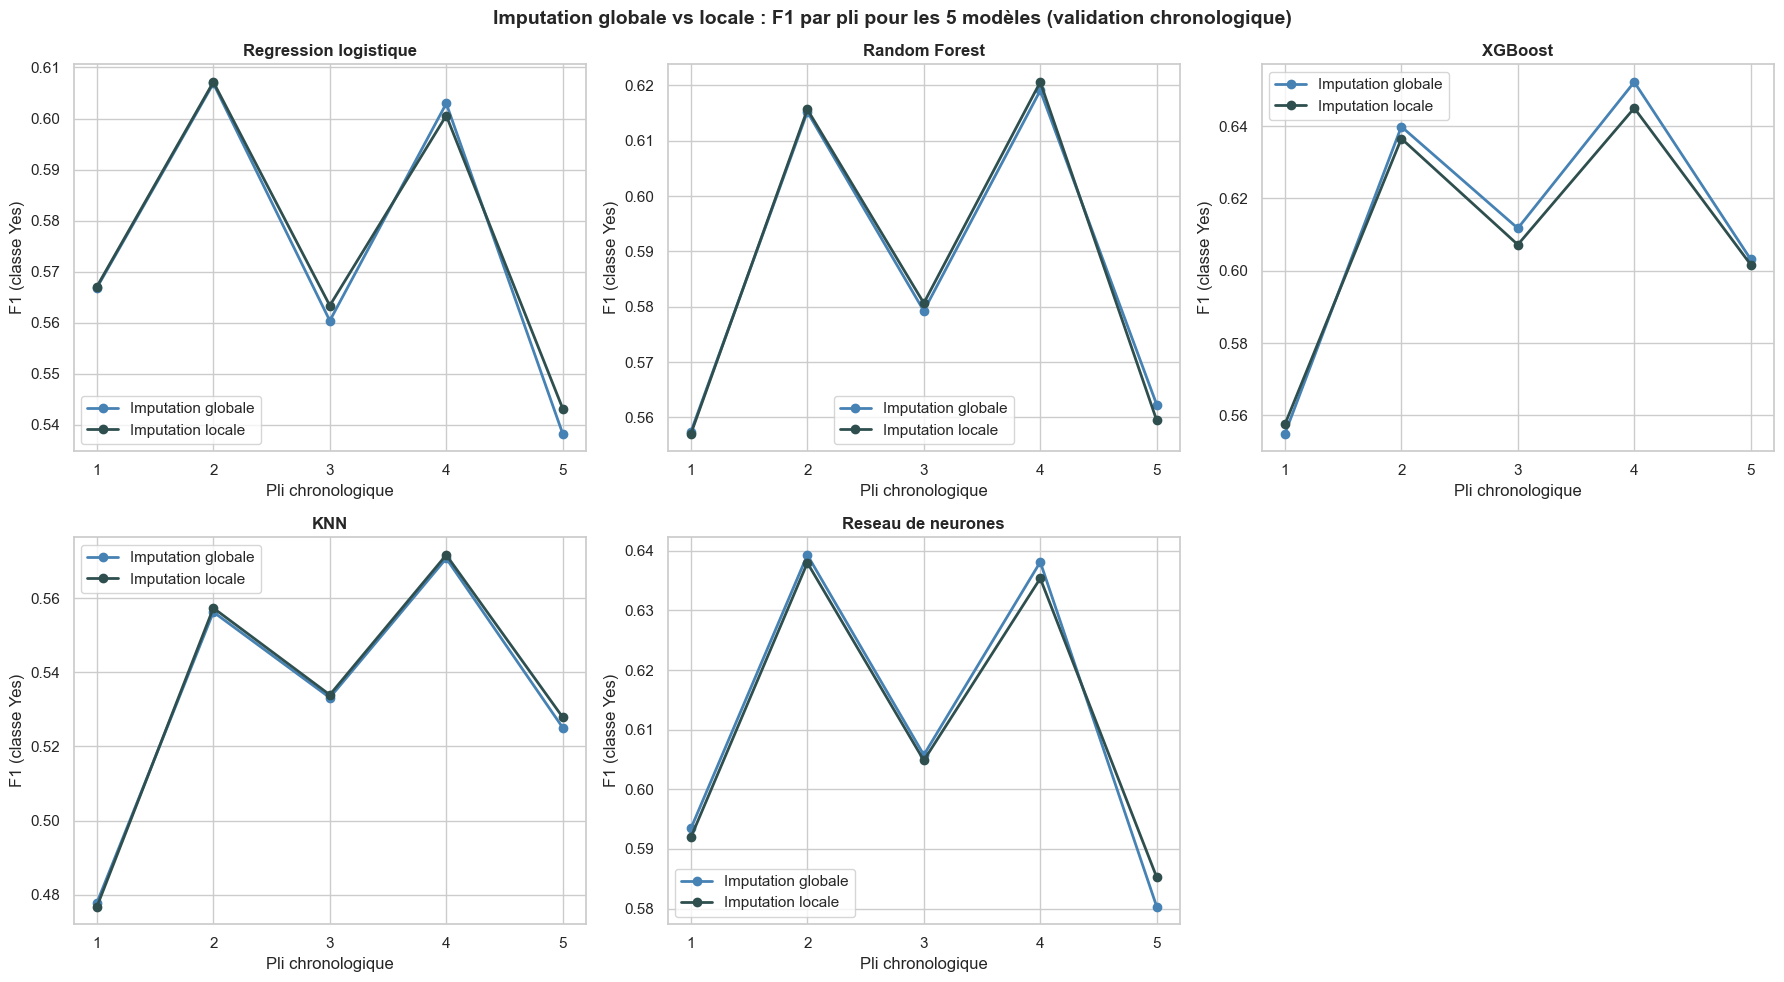

In [34]:
# CELL 34: Visualisation de la comparaison (5 modèles)

numeros_plis = np.arange(1, len(plis) + 1)

# Une grille 2 x 3 : un sous-graphique par modèle
plt.figure(figsize=(18, 10))

for i in range(len(modeles_5)):
    plt.subplot(2, 3, i + 1)
    plt.plot(numeros_plis, f1_globale_par_modele[i], marker='o', linewidth=2, color='steelblue',
             label="Imputation globale")
    plt.plot(numeros_plis, f1_locale_par_modele[i], marker='o', linewidth=2, color='darkslategray',
             label="Imputation locale")
    plt.title(modeles_5[i], fontsize=12, fontweight='bold')
    plt.xlabel("Pli chronologique")
    plt.ylabel("F1 (classe Yes)")
    plt.xticks(numeros_plis)
    plt.legend()

plt.suptitle("Imputation globale vs locale : F1 par pli pour les 5 modèles (validation chronologique)",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/etape2_05_imputation_globale_vs_locale.png', dpi=150)
print("Figure sauvegardée: figures/etape2_05_imputation_globale_vs_locale.png")
plt.show()

In [35]:
# CELL 35: Statistiques d'imputation calculées sur X_train (méthode retenue)

# Méthode retenue : variable methode_retenue, fixée par la règle de décision de la comparaison
# sur les 5 modèles (CELL 33). Fonctions de CELL 20 à CELL 22.
print(f"Méthode d'imputation appliquée: {methode_retenue}")

# Statistiques calculées une seule fois sur les valeurs mesurées de X_train
stats_globales, stats_locales = calculer_stats_imputation(X_train)
ecarts_globaux, ecarts_locaux = calculer_ecarts_types(X_train)
colonnes_imputees = cols_mediane + cols_moyenne + cols_mode

Méthode d'imputation appliquée: locale


In [36]:
# CELL 36: Écarts typiques 15h - 9h par station (objets conservés pour Streamlit)

# - ecarts_types_global : écart typique 15h - 9h global de chaque paire
# - ecarts_types_local : écart typique par Location (repli sur l'écart global inclus)
ecarts_types_global = dict(ecarts_globaux)

# Table des écarts par station : une ligne par station de X_train (ordre alphabétique), index = Location
ecarts_types_local = pd.DataFrame({'Location': sorted(X_train['Location'].unique())})
for var_diff in paires_diff:
    ecarts_types_local[var_diff] = ecarts_types_local['Location'].map(ecarts_locaux[var_diff])
ecarts_types_local = ecarts_types_local.set_index('Location')

# Stations sans paire complète : repli sur l'écart global
repli_ecarts = []
for var_diff in paires_diff:
    for loc in ecarts_types_local.index[ecarts_types_local[var_diff].isnull()]:
        repli_ecarts.append(f"{loc} - {var_diff}")
    ecarts_types_local[var_diff] = ecarts_types_local[var_diff].fillna(ecarts_types_global[var_diff])

In [37]:
# CELL 37: Statistiques d'imputation par station (objets conservés pour Streamlit)

# - impute_global : statistiques globales des 12 + 4 variables
# - impute_local : table Location x variable (repli sur la statistique globale inclus)
impute_global = dict(stats_globales)
colonnes_impute_local = {}
for col in colonnes_imputees:
    colonnes_impute_local[col] = stats_locales[col]
impute_local = pd.DataFrame(colonnes_impute_local)

# Stations sans valeur pour une variable : repli sur la statistique globale
repli_variables = []
for col in colonnes_imputees:
    for loc in impute_local.index[impute_local[col].isnull()]:
        repli_variables.append(f"{loc} - {col}")
    impute_local[col] = impute_local[col].fillna(impute_global[col])

In [38]:
# CELL 38: Valeurs imputées à partir de l'autre valeur de la paire

# Masques conservés AVANT imputation (utilisés en CELL 45) :
# paire avec exactement une valeur manquante (imputée à partir de l'autre) / deux valeurs manquantes
masque_une_imputee = {}
masque_deux_imputees = {}
print("\nValeurs imputées à partir de l'autre valeur de la paire:")
for var_diff in paires_diff:
    col_9h = paires_diff[var_diff][0]
    col_15h = paires_diff[var_diff][1]
    # X_train
    une = X_train[col_9h].isnull() != X_train[col_15h].isnull()
    deux = X_train[col_9h].isnull() & X_train[col_15h].isnull()
    masque_une_imputee[var_diff] = une
    masque_deux_imputees[var_diff] = deux
    nb_9h = int((X_train[col_9h].isnull() & (X_train[col_15h].isnull() == False)).sum())
    nb_15h = int((X_train[col_15h].isnull() & (X_train[col_9h].isnull() == False)).sum())
    print(f"  {col_9h} / {col_15h} | X_train: {int(une.sum())} valeurs ({nb_9h} à 9h, {nb_15h} à 15h) | "
          f"paires entièrement manquantes: {int(deux.sum())}")
    # X_test
    une = X_test[col_9h].isnull() != X_test[col_15h].isnull()
    deux = X_test[col_9h].isnull() & X_test[col_15h].isnull()
    nb_9h = int((X_test[col_9h].isnull() & (X_test[col_15h].isnull() == False)).sum())
    nb_15h = int((X_test[col_15h].isnull() & (X_test[col_9h].isnull() == False)).sum())
    print(f"  {col_9h} / {col_15h} | X_test: {int(une.sum())} valeurs ({nb_9h} à 9h, {nb_15h} à 15h) | "
          f"paires entièrement manquantes: {int(deux.sum())}")


Valeurs imputées à partir de l'autre valeur de la paire:
  Temp9am / Temp3pm | X_train: 1265 valeurs (543 à 9h, 722 à 15h) | paires entièrement manquantes: 264
  Temp9am / Temp3pm | X_test: 1659 valeurs (8 à 9h, 1651 à 15h) | paires entièrement manquantes: 89
  Humidity9am / Humidity3pm | X_train: 1497 valeurs (639 à 9h, 858 à 15h) | paires entièrement manquantes: 837
  Humidity9am / Humidity3pm | X_test: 1691 valeurs (37 à 9h, 1654 à 15h) | paires entièrement manquantes: 261
  Pressure9am / Pressure3pm | X_train: 387 valeurs (211 à 9h, 176 à 15h) | paires entièrement manquantes: 10857
  Pressure9am / Pressure3pm | X_test: 26 valeurs (12 à 9h, 14 à 15h) | paires entièrement manquantes: 2934


In [39]:
# CELL 39: Imputation des valeurs manquantes de X_train et X_test

# Application des MÊMES statistiques (calculées sur X_train, CELL 35) à X_train et à X_test :
# paires selon leur lien, puis le reste
X_train = imputer_paires(X_train, methode_retenue, ecarts_globaux, ecarts_locaux)
X_train = imputer_reste(X_train, methode_retenue, stats_globales, stats_locales)
X_test = imputer_paires(X_test, methode_retenue, ecarts_globaux, ecarts_locaux)
X_test = imputer_reste(X_test, methode_retenue, stats_globales, stats_locales)

# Cas de repli (utiles seulement avec la méthode locale)
if methode_retenue == 'locale':
    print(f"\nStations sans paire complète (écart global utilisé) ({len(repli_ecarts)}):")
    for repli in repli_ecarts:
        print(f"  {repli}")
    print(f"\nCouples (Location, variable) avec repli sur la statistique globale ({len(repli_variables)}):")
    for repli in repli_variables:
        print(f"  {repli}")
else:
    print("\nMéthode globale : aucun repli nécessaire (une seule statistique par variable et par paire).")


Stations sans paire complète (écart global utilisé) (4):
  MountGinini - Pressure_diff
  Newcastle - Pressure_diff
  Penrith - Pressure_diff
  SalmonGums - Pressure_diff

Couples (Location, variable) avec repli sur la statistique globale (12):
  Albany - WindGustSpeed
  Newcastle - WindGustSpeed
  MountGinini - Pressure9am
  Newcastle - Pressure9am
  Penrith - Pressure9am
  SalmonGums - Pressure9am
  MountGinini - Pressure3pm
  Newcastle - Pressure3pm
  Penrith - Pressure3pm
  SalmonGums - Pressure3pm
  Albany - WindGustDir
  Newcastle - WindGustDir


In [40]:
# CELL 40: Valeurs manquantes restantes après imputation

print("\nValeurs manquantes restantes dans X_train:")
print(X_train.isnull().sum())
print("\nValeurs manquantes restantes dans X_test:")
print(X_test.isnull().sum())


Valeurs manquantes restantes dans X_train:
Date             0
Location         0
MinTemp          0
MaxTemp          0
Rainfall         0
WindGustDir      0
WindGustSpeed    0
WindDir9am       0
WindDir3pm       0
WindSpeed9am     0
WindSpeed3pm     0
Humidity9am      0
Humidity3pm      0
Pressure9am      0
Pressure3pm      0
Temp9am          0
Temp3pm          0
RainToday        0
dtype: int64

Valeurs manquantes restantes dans X_test:
Date             0
Location         0
MinTemp          0
MaxTemp          0
Rainfall         0
WindGustDir      0
WindGustSpeed    0
WindDir9am       0
WindDir3pm       0
WindSpeed9am     0
WindSpeed3pm     0
Humidity9am      0
Humidity3pm      0
Pressure9am      0
Pressure3pm      0
Temp9am          0
Temp3pm          0
RainToday        0
dtype: int64


In [41]:
# CELL 41: Récapitulatif des valeurs d'imputation : variables imputées (calculées sur X_train)

# Réutilisation des objets de CELL 36 et CELL 37 (impute_global, impute_local), aucun recalcul.
# Valeurs par station : repli sur la valeur globale inclus.
variables_paires = []
for var_diff in paires_diff:
    variables_paires.append(paires_diff[var_diff][0])
    variables_paires.append(paires_diff[var_diff][1])

lignes_recap = []
for col in colonnes_imputees:
    methode = 'mode'
    if col in cols_mediane:
        methode = 'mediane'
    elif col in cols_moyenne:
        methode = 'moyenne'
    # Variables des paires 9h / 15h : d'abord imputées à partir de l'autre valeur de la paire,
    # puis par la statistique de la station si les deux valeurs manquent
    if col in variables_paires:
        methode = f"imputation par la paire 9h-15h, puis {methode}"
    # Variable catégorielle : pas de minimum / maximum
    valeur_globale = impute_global[col]
    val_min = '-'
    val_max = '-'
    if col not in cols_mode:
        valeur_globale = round(impute_global[col], 2)
        val_min = round(impute_local[col].min(), 2)
        val_max = round(impute_local[col].max(), 2)
    lignes_recap.append({'Variable': col, 'Méthode': methode, 'Valeur_globale': valeur_globale,
                         'Min_stations': val_min, 'Max_stations': val_max})

In [42]:
# CELL 42: Récapitulatif des valeurs d'imputation : écarts typiques 15h - 9h

# Écarts typiques utilisés pour l'imputation par la paire (CELL 36)
for var_diff in paires_diff:
    col_9h = paires_diff[var_diff][0]
    col_15h = paires_diff[var_diff][1]
    lignes_recap.append({
        'Variable': f"Écart {col_15h} - {col_9h}",
        'Méthode': f"écart typique ({regle_ecart[var_diff]})",
        'Valeur_globale': round(ecarts_types_global[var_diff], 2),
        'Min_stations': round(ecarts_types_local[var_diff].min(), 2),
        'Max_stations': round(ecarts_types_local[var_diff].max(), 2)
    })

table_recap_imputation = pd.DataFrame(lignes_recap)
print("Valeurs d'imputation (calculées sur X_train, méthode locale):")
print(table_recap_imputation)

Valeurs d'imputation (calculées sur X_train, méthode locale):
                           Variable                                       Méthode Valeur_globale Min_stations Max_stations
0                          Rainfall                                       mediane            0.0          0.0          0.2
1                     WindGustSpeed                                       mediane           39.0         28.0         46.0
2                      WindSpeed9am                                       mediane           13.0          4.0         20.0
3                      WindSpeed3pm                                       mediane           19.0          7.0         26.0
4                           MinTemp                                       moyenne          11.95         3.39        22.99
5                           MaxTemp                                       moyenne          22.96        11.47        34.79
6                           Temp9am  imputation par la paire 9h-15h, puis moy

In [43]:
# CELL 43: Fonctions de création des nouvelles variables

# Saison de l'hémisphère sud (Australie) à partir du mois, été = décembre à février, automne = mars à mai, hiver = juin à août, printemps = septembre à novembre
def get_saison(mois):
    if mois in [12, 1, 2]:
        return 'Ete'
    elif mois in [3, 4, 5]:
        return 'Automne'
    elif mois in [6, 7, 8]:
        return 'Hiver'
    else:
        return 'Printemps'


# Feature engineering : transformation ligne à ligne, aucune statistique ajustée
# Season est réintégrée
def creer_variables(X):
    X = X.copy()
    X['Date'] = pd.to_datetime(X['Date'])
    X['Month'] = X['Date'].dt.month
    X['Season'] = X['Month'].apply(get_saison)
    X['Temp_diff'] = X['Temp3pm'] - X['Temp9am']
    X['Humidity_diff'] = X['Humidity3pm'] - X['Humidity9am']
    X['Pressure_diff'] = X['Pressure3pm'] - X['Pressure9am']
    return X


# Numérotation des saisons dans l'ordre du cycle (Ete=0, Automne=1, Hiver=2, Printemps=3),
# utilisée pour la corrélation (CELL 47) et l'encodage (CELL 50)
saisons = ['Ete', 'Automne', 'Hiver', 'Printemps']
numero_saison = {}
for i in range(len(saisons)):
    numero_saison[saisons[i]] = i

In [44]:
# CELL 44: Création des nouvelles variables (après imputation)

# Application à X_train et X_test
X_train = creer_variables(X_train)
X_test = creer_variables(X_test)

nouvelles_colonnes = ['Month', 'Season', 'Temp_diff', 'Humidity_diff', 'Pressure_diff']
print("Nouvelles variables (X_train), aperçu:")
print(X_train[nouvelles_colonnes].head())

# Les nouvelles colonnes sont-elles toutes présentes dans X_test ?
toutes_presentes = True
for c in nouvelles_colonnes:
    if c not in X_test.columns:
        toutes_presentes = False
print(f"\nMêmes colonnes présentes dans X_test: {toutes_presentes}")
print(f"Dimensions X_train: {X_train.shape} | X_test: {X_test.shape}")

Nouvelles variables (X_train), aperçu:
   Month     Season  Temp_diff  Humidity_diff  Pressure_diff
0     11  Printemps        9.2          -39.0           -4.7
1     11  Printemps        8.2          -44.0           -4.0
2     11  Printemps        4.8          -13.0           -2.3
3     11  Printemps        0.6           -6.0            1.5
4     11  Printemps        4.3          -19.0            0.2

Mêmes colonnes présentes dans X_test: True
Dimensions X_train: (113748, 23) | X_test: (28445, 23)


In [45]:
# CELL 45: Valeurs aberrantes des variables créées (méthode IQR, X_train)

# Bornes IQR de CELL 16 : calculées sur les écarts MESURÉS (paires complètes) uniquement,
# jamais sur des valeurs imputées (même définition qu'en CELL 10). Masques de CELL 38, avant imputation.
variables_diff = list(paires_diff.keys())


def afficher_groupe(nom_groupe, masque_groupe, masque_out, col):
    # Nombre de lignes, valeurs aberrantes, minimum et maximum d'un groupe de lignes
    nb_lignes = int(masque_groupe.sum())
    nb_out = int((masque_out & masque_groupe).sum())
    # Groupe vide : 0 valeur aberrante sur 0 ligne, pourcentage 0
    pct_out = nb_out / max(nb_lignes, 1) * 100
    valeurs = X_train.loc[masque_groupe, col]
    print(f"  {nom_groupe}: {nb_lignes} lignes | {nb_out} valeurs aberrantes ({pct_out:.2f}%) | "
          f"min = {valeurs.min():.2f} | max = {valeurs.max():.2f}")


print("Valeurs aberrantes des variables créées selon l'origine des valeurs de la paire (X_train),")
print("bornes IQR des écarts mesurés (CELL 16):")
for col in variables_diff:
    borne_inf = bornes_ecarts_mesures[col][0]
    borne_sup = bornes_ecarts_mesures[col][1]
    masque_out = (X_train[col] < borne_inf) | (X_train[col] > borne_sup)
    une = masque_une_imputee[col]
    deux = masque_deux_imputees[col]
    print(f"\n{col} (bornes: {borne_inf:.2f} / {borne_sup:.2f}):")
    afficher_groupe('Deux valeurs mesurées', (une == False) & (deux == False), masque_out, col)
    afficher_groupe('Une valeur imputée par la paire', une, masque_out, col)
    afficher_groupe('Deux valeurs imputées', deux, masque_out, col)

Valeurs aberrantes des variables créées selon l'origine des valeurs de la paire (X_train),
bornes IQR des écarts mesurés (CELL 16):

Temp_diff (bornes: -5.55 / 14.85):
  Deux valeurs mesurées: 112219 lignes | 634 valeurs aberrantes (0.56%) | min = -12.60 | max = 23.00
  Une valeur imputée par la paire: 1265 lignes | 0 valeurs aberrantes (0.00%) | min = 0.76 | max = 8.20
  Deux valeurs imputées: 264 lignes | 0 valeurs aberrantes (0.00%) | min = 1.75 | max = 7.41

Humidity_diff (bornes: -61.00 / 27.00):
  Deux valeurs mesurées: 111414 lignes | 1127 valeurs aberrantes (1.01%) | min = -91.00 | max = 91.00
  Une valeur imputée par la paire: 1497 lignes | 0 valeurs aberrantes (0.00%) | min = -28.87 | max = -2.51
  Deux valeurs imputées: 837 lignes | 0 valeurs aberrantes (0.00%) | min = -28.88 | max = -2.49

Pressure_diff (bornes: -7.30 / 2.30):
  Deux valeurs mesurées: 102504 lignes | 2725 valeurs aberrantes (2.66%) | min = -16.70 | max = 10.80
  Une valeur imputée par la paire: 387 lignes |


Figure sauvegardée: figures/etape2_07_outliers_iqr_differences.png


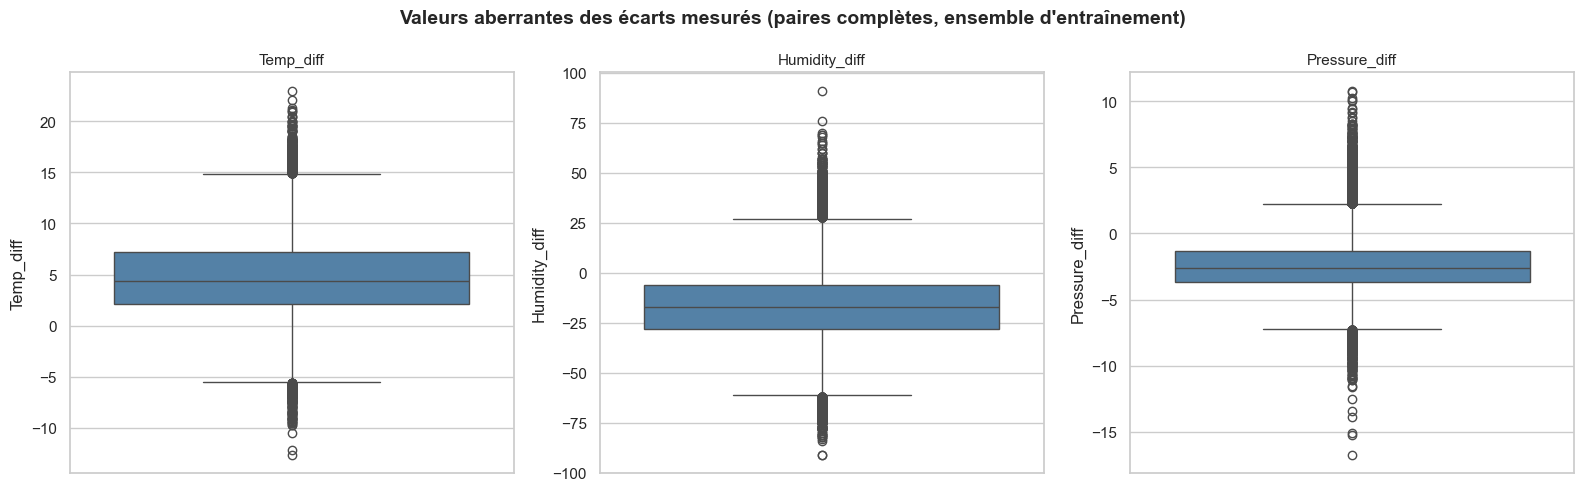

In [46]:
# CELL 46: Boxplots des écarts mesurés (paires complètes, X_train)

# Écarts mesurés uniquement (paires complètes), même style qu'en CELL 11
plt.figure(figsize=(16, 5))
for i in range(len(variables_diff)):
    col = variables_diff[i]
    masque_mesure = (masque_une_imputee[col] == False) & (masque_deux_imputees[col] == False)
    plt.subplot(1, 3, i + 1)
    sns.boxplot(y=X_train.loc[masque_mesure, col], color='steelblue')
    plt.title(col, fontsize=11)
    plt.ylabel(col)

plt.suptitle("Valeurs aberrantes des écarts mesurés (paires complètes, ensemble d'entraînement)",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/etape2_07_outliers_iqr_differences.png', dpi=150)
print("\nFigure sauvegardée: figures/etape2_07_outliers_iqr_differences.png")
plt.show()

In [47]:
# CELL 47: Corrélation des nouvelles variables numériques avec la cible

from scipy.stats import spearmanr

# Cible numérique temporaire sur le jeu d'entraînement uniquement (cible J+1)
y_train_bin = (y_train == 'Yes').astype(int)

# Nouvelles variables ; Season est numérotée dans l'ordre du cycle (numero_saison, CELL 43)
features_creees = ['Temp_diff', 'Humidity_diff', 'Pressure_diff', 'Month', 'Season']
X_corr = X_train[['Temp_diff', 'Humidity_diff', 'Pressure_diff', 'Month']].copy()
X_corr['Season'] = X_train['Season'].map(numero_saison)

# Corrélations de Pearson et de Spearman avec la cible (sur X_train)
lignes_corr = []
for col in features_creees:
    lignes_corr.append({
        'Variable': col,
        'Pearson': X_corr[col].corr(y_train_bin),
        'Spearman': spearmanr(X_corr[col], y_train_bin)[0]
    })
table_corr_nouvelles = pd.DataFrame(lignes_corr)
# Tri par |Pearson| décroissant : colonne de la valeur absolue, tri, puis suppression de la colonne
table_corr_nouvelles['abs_Pearson'] = np.abs(table_corr_nouvelles['Pearson'])
table_corr_nouvelles = table_corr_nouvelles.sort_values('abs_Pearson', ascending=False).reset_index().drop(columns=['index'])
table_corr_nouvelles = table_corr_nouvelles.drop(columns=['abs_Pearson'])

# Affichage arrondi à 4 décimales
table_affichage = table_corr_nouvelles.copy()
pearson_arrondis = []
for v in table_affichage['Pearson'].values:
    pearson_arrondis.append(round(v, 4))
spearman_arrondis = []
for v in table_affichage['Spearman'].values:
    spearman_arrondis.append(round(v, 4))
table_affichage['Pearson'] = pearson_arrondis
table_affichage['Spearman'] = spearman_arrondis
print("Corrélation des nouvelles variables avec la cible (X_train, RainTomorrow):")
print(table_affichage)

Corrélation des nouvelles variables avec la cible (X_train, RainTomorrow):
        Variable  Pearson  Spearman
0      Temp_diff  -0.3259   -0.3332
1  Humidity_diff   0.2631    0.2561
2  Pressure_diff   0.0824    0.0848
3         Season   0.0133    0.0127
4          Month   0.0096    0.0087



Figure sauvegardée: figures/etape2_06_correlation_features_creees.png


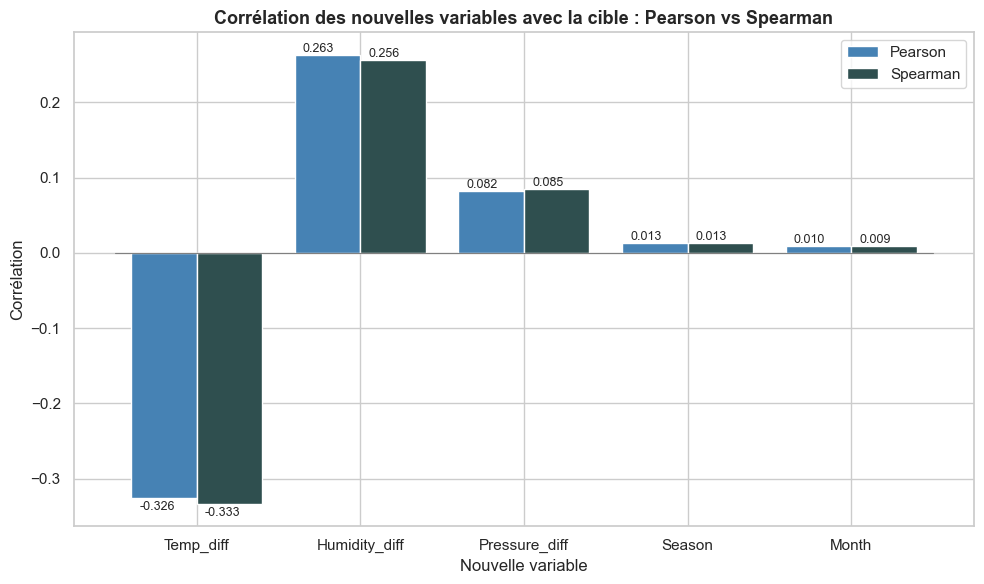

In [48]:
# CELL 48: Graphique de la corrélation des nouvelles variables avec la cible (Pearson vs Spearman)

ordre = table_corr_nouvelles['Variable'].tolist()
valeurs_pearson = table_corr_nouvelles['Pearson'].tolist()
valeurs_spearman = table_corr_nouvelles['Spearman'].tolist()
x = np.arange(len(ordre))
largeur = 0.4

plt.figure(figsize=(10, 6))
plt.bar(x - largeur / 2, valeurs_pearson, width=largeur, label='Pearson', color='steelblue')
plt.bar(x + largeur / 2, valeurs_spearman, width=largeur, label='Spearman', color='darkslategray')
# Valeur au-dessus (ou au-dessous si négative) de chaque barre, texte décalé vers la gauche pour rester centré
for i in range(len(ordre)):
    y_pearson = valeurs_pearson[i] + 0.004
    if valeurs_pearson[i] < 0:
        y_pearson = valeurs_pearson[i] - 0.016
    y_spearman = valeurs_spearman[i] + 0.004
    if valeurs_spearman[i] < 0:
        y_spearman = valeurs_spearman[i] - 0.016
    plt.text(x[i] - largeur / 2 - 0.15, y_pearson, f"{valeurs_pearson[i]:.3f}", fontsize=9)
    plt.text(x[i] + largeur / 2 - 0.15, y_spearman, f"{valeurs_spearman[i]:.3f}", fontsize=9)
# Ligne horizontale de référence en 0
plt.plot([-0.5, len(ordre) - 0.5], [0, 0], color='gray', linewidth=0.8)
plt.title("Corrélation des nouvelles variables avec la cible : Pearson vs Spearman",
          fontsize=13, fontweight='bold')
plt.xlabel("Nouvelle variable")
plt.ylabel("Corrélation")
plt.xticks(x, ordre)
plt.legend()
plt.tight_layout()
plt.savefig('../figures/etape2_06_correlation_features_creees.png', dpi=150)
print("\nFigure sauvegardée: figures/etape2_06_correlation_features_creees.png")
plt.show()

In [49]:
# CELL 49: Encodage des cibles

# Décisions d'encodage des variables explicatives (CELL 50 à CELL 52) :
# - Month, Season et les 3 directions du vent sont des variables cycliques (décembre est proche de janvier,
#   NNW est proche de N, le printemps précède l'été) : encodage trigonométrique (sin / cos) avec encode_cyclical
# - directions : les 16 points cardinaux sont numérotés dans l'ordre de la rose des vents
#   (N=0, NNE=1, ..., NNW=15), puis encodés sur un cycle de 16
# - Season : saisons numérotées dans l'ordre du cycle (numero_saison, CELL 43 : Ete=0, Automne=1,
#   Hiver=2, Printemps=3), puis encodées sur un cycle de 4
# - RainToday : No -> 0, Yes -> 1
# - Location : remplacée par le taux de pluie de la station (moyenne de la cible par Location),
#   calculé sur les données d'entraînement uniquement
# encode_cyclical, numero_direction et cols_directions : définis en CELL 24

# RainTomorrow : Yes -> 1, No -> 0
y_train_enc = (y_train == 'Yes').astype(int)
y_test_enc = (y_test == 'Yes').astype(int)
# RainInTwoDays : Yes -> 1, No -> 0, valeurs manquantes conservées
y2_train_enc = y2_train.map({'No': 0, 'Yes': 1})
y2_test_enc = y2_test.map({'No': 0, 'Yes': 1})

In [50]:
# CELL 50: Encodage de RainToday, Month et Season (X_train et X_test)

# RainToday : No -> 0, Yes -> 1
X_train['RainToday'] = X_train['RainToday'].map({'No': 0, 'Yes': 1})
X_test['RainToday'] = X_test['RainToday'].map({'No': 0, 'Yes': 1})

# Month : cycle de 12
X_train = encode_cyclical(X_train, 'Month', 12)
X_test = encode_cyclical(X_test, 'Month', 12)

# Season : numéro 0 à 3 dans l'ordre du cycle, puis cycle de 4
X_train['Season'] = X_train['Season'].map(numero_saison)
X_test['Season'] = X_test['Season'].map(numero_saison)
X_train = encode_cyclical(X_train, 'Season', 4)
X_test = encode_cyclical(X_test, 'Season', 4)

In [51]:
# CELL 51: Encodage des directions du vent (X_train et X_test)

# Directions du vent : numéro 0 à 15 (numero_direction, CELL 24), puis cycle de 16
X_train['WindGustDir'] = X_train['WindGustDir'].map(numero_direction)
X_train = encode_cyclical(X_train, 'WindGustDir', 16)
X_train['WindDir9am'] = X_train['WindDir9am'].map(numero_direction)
X_train = encode_cyclical(X_train, 'WindDir9am', 16)
X_train['WindDir3pm'] = X_train['WindDir3pm'].map(numero_direction)
X_train = encode_cyclical(X_train, 'WindDir3pm', 16)
X_test['WindGustDir'] = X_test['WindGustDir'].map(numero_direction)
X_test = encode_cyclical(X_test, 'WindGustDir', 16)
X_test['WindDir9am'] = X_test['WindDir9am'].map(numero_direction)
X_test = encode_cyclical(X_test, 'WindDir9am', 16)
X_test['WindDir3pm'] = X_test['WindDir3pm'].map(numero_direction)
X_test = encode_cyclical(X_test, 'WindDir3pm', 16)

# Date, Month, Season et les 3 directions d'origine sont remplacées par leurs colonnes sin / cos
X_train = X_train.drop(columns=['Date', 'Month', 'Season'] + cols_directions)
X_test = X_test.drop(columns=['Date', 'Month', 'Season'] + cols_directions)

In [52]:
# CELL 52: Encodage de Location (taux de pluie par station, calculé sur les données d'entraînement)

# Location_encoded (modèle J+1) : taux de pluie RainTomorrow par Location sur X_train
loc_rate_J1 = y_train_enc.groupby(X_train['Location']).mean()
taux_global_J1 = y_train_enc.mean()
# Location_encoded_J2 (modèle J+2) : taux de pluie RainInTwoDays par Location,
# sur les lignes de X_train où RainInTwoDays n'est pas manquant
masque_j2 = y2_train_enc.isnull() == False
loc_rate_J2 = y2_train_enc[masque_j2].groupby(X_train.loc[masque_j2, 'Location']).mean()
taux_global_J2 = y2_train_enc[masque_j2].mean()

# Localité absente des données d'entraînement : taux global de la cible correspondante
X_train['Location_encoded'] = X_train['Location'].map(loc_rate_J1).fillna(taux_global_J1)
X_train['Location_encoded_J2'] = X_train['Location'].map(loc_rate_J2).fillna(taux_global_J2)
X_test['Location_encoded'] = X_test['Location'].map(loc_rate_J1).fillna(taux_global_J1)
X_test['Location_encoded_J2'] = X_test['Location'].map(loc_rate_J2).fillna(taux_global_J2)

X_train = X_train.drop(columns=['Location'])
X_test = X_test.drop(columns=['Location'])

# Conservés pour Streamlit : numero_direction (CELL 24), numero_saison (CELL 43), loc_rate_J1, loc_rate_J2,
# taux_global_J1, taux_global_J2
print(f"Taux global J+1 (RainTomorrow): {taux_global_J1:.4f} | taux global J+2 (RainInTwoDays): {taux_global_J2:.4f}")
print(f"Localités encodées: J+1 = {len(loc_rate_J1)}, J+2 = {len(loc_rate_J2)}")

Taux global J+1 (RainTomorrow): 0.2244 | taux global J+2 (RainInTwoDays): 0.2218
Localités encodées: J+1 = 49, J+2 = 49


In [53]:
# CELL 53: Dimensions et colonnes sin / cos après encodage

print(f"\nDimensions finales X_train: {X_train.shape}")
print(f"Dimensions finales X_test:  {X_test.shape}")
print(f"\nColonnes ({X_train.shape[1]}): {list(X_train.columns)}")
print(f"\nColonnes identiques entre X_train et X_test: {list(X_train.columns) == list(X_test.columns)}")
print(f"Valeurs manquantes restantes: X_train = {int(X_train.isnull().sum().sum())}, "
      f"X_test = {int(X_test.isnull().sum().sum())}")

# Liste des 10 colonnes sin / cos, dans l'ordre des colonnes de X_train
cols_trigo = []
for var in ['Month', 'Season'] + cols_directions:
    cols_trigo.append(var + '_sin')
    cols_trigo.append(var + '_cos')

print(f"\nVérification des colonnes sin / cos (doivent être comprises entre -1 et 1):")
for col in cols_trigo:
    dans_bornes_train = ((X_train[col] >= -1) & (X_train[col] <= 1)).all()
    dans_bornes_test = ((X_test[col] >= -1) & (X_test[col] <= 1)).all()
    dans_bornes = dans_bornes_train and dans_bornes_test
    print(f"  {col} min = {min(X_train[col].min(), X_test[col].min()):.4f} | "
          f"max = {max(X_train[col].max(), X_test[col].max()):.4f} | entre -1 et 1: {dans_bornes}")


Dimensions finales X_train: (113748, 28)
Dimensions finales X_test:  (28445, 28)

Colonnes (28): ['MinTemp', 'MaxTemp', 'Rainfall', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Temp9am', 'Temp3pm', 'RainToday', 'Temp_diff', 'Humidity_diff', 'Pressure_diff', 'Month_sin', 'Month_cos', 'Season_sin', 'Season_cos', 'WindGustDir_sin', 'WindGustDir_cos', 'WindDir9am_sin', 'WindDir9am_cos', 'WindDir3pm_sin', 'WindDir3pm_cos', 'Location_encoded', 'Location_encoded_J2']

Colonnes identiques entre X_train et X_test: True
Valeurs manquantes restantes: X_train = 0, X_test = 0

Vérification des colonnes sin / cos (doivent être comprises entre -1 et 1):
  Month_sin min = -1.0000 | max = 1.0000 | entre -1 et 1: True
  Month_cos min = -1.0000 | max = 1.0000 | entre -1 et 1: True
  Season_sin min = -1.0000 | max = 1.0000 | entre -1 et 1: True
  Season_cos min = -1.0000 | max = 1.0000 | entre -1 et 1: True
  WindGustDir_sin min = -1.0000 |

Figure sauvegardée: figures/etape2_08_location_target_encoding.png


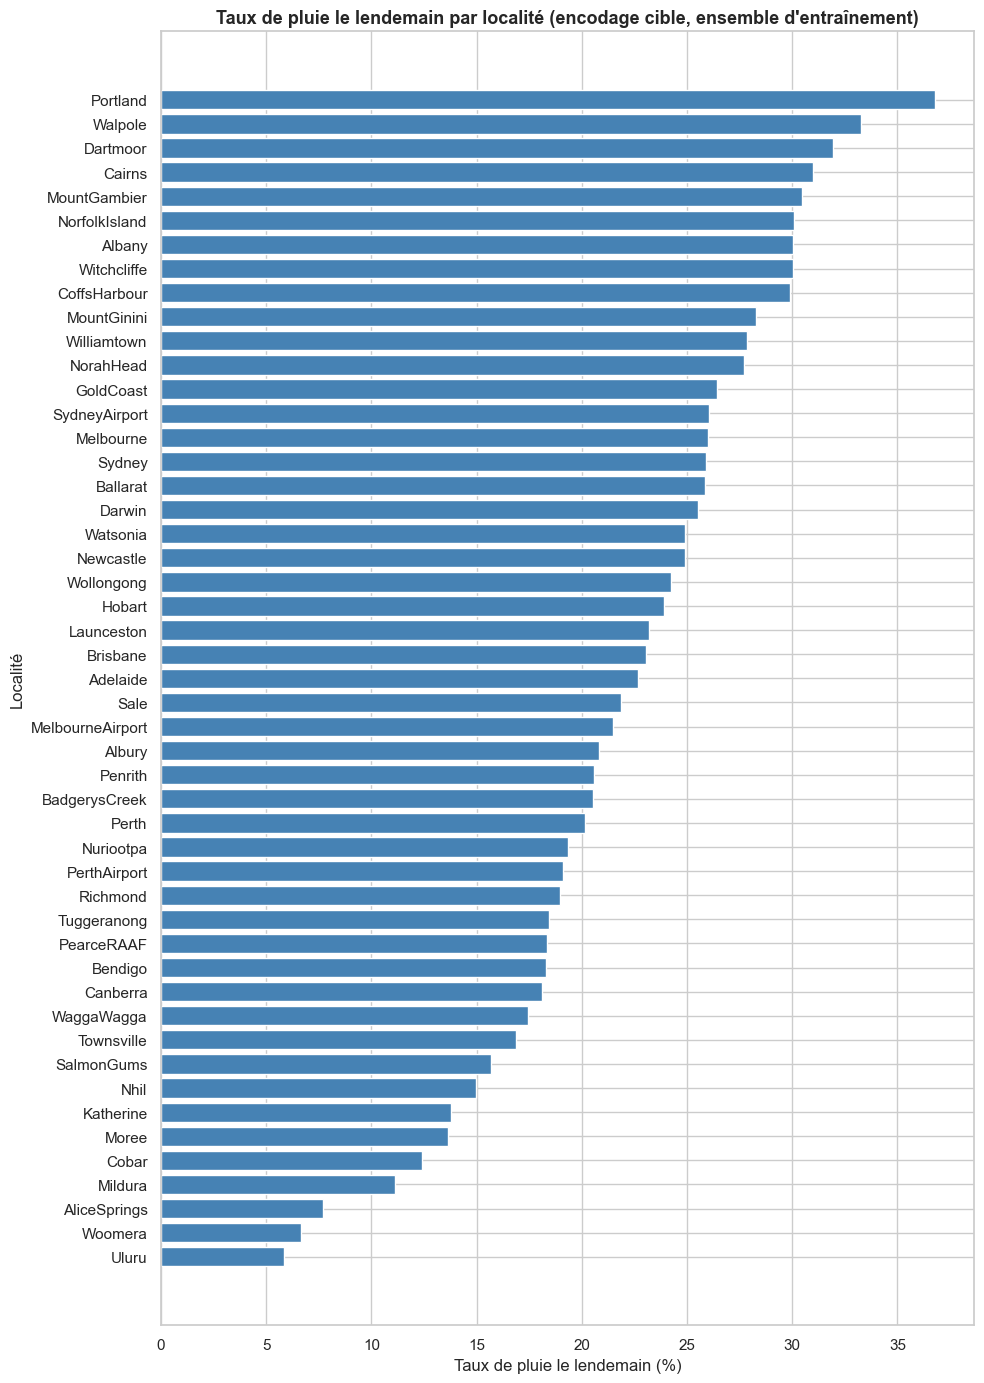


Top 5 localités les plus pluvieuses (taux %):
       Location   Taux
0      Portland  36.80
1       Walpole  33.27
2      Dartmoor  31.94
3        Cairns  31.00
4  MountGambier  30.46

Top 5 localités les plus sèches (taux %):
       Location   Taux
0         Cobar  12.41
1       Mildura  11.11
2  AliceSprings   7.69
3       Woomera   6.65
4         Uluru   5.87


In [54]:
# CELL 54: Visualisation de l'encodage de Location (taux de pluie par localité, J+1)

# Réutilisation du mapping loc_rate_J1 calculé sur X_train en CELL 52 (aucun recalcul, données d'entraînement)
# Expression en pourcentage, trié du plus pluvieux au plus sec
loc_rate_pct = (loc_rate_J1 * 100).sort_values(ascending=False)

# Tracé : tri croissant pour afficher le plus pluvieux en haut du graphique
donnees = loc_rate_pct.sort_values(ascending=True)

plt.figure(figsize=(10, 14))
plt.barh(donnees.index, donnees.values, color='steelblue')
plt.title("Taux de pluie le lendemain par localité (encodage cible, ensemble d'entraînement)",
          fontsize=13, fontweight='bold')
plt.xlabel("Taux de pluie le lendemain (%)")
plt.ylabel("Localité")
plt.tight_layout()
plt.savefig('../figures/etape2_08_location_target_encoding.png', dpi=150)
print("Figure sauvegardée: figures/etape2_08_location_target_encoding.png")
plt.show()

# Top 5 (plus pluvieuses) et bottom 5 (plus sèches), taux arrondis à 2 décimales
taux_pluvieuses = []
for v in loc_rate_pct.head(5).values:
    taux_pluvieuses.append(round(v, 2))
taux_seches = []
for v in loc_rate_pct.tail(5).values:
    taux_seches.append(round(v, 2))
top_5_pluvieuses = pd.DataFrame({'Location': loc_rate_pct.head(5).index, 'Taux': taux_pluvieuses})
top_5_seches = pd.DataFrame({'Location': loc_rate_pct.tail(5).index, 'Taux': taux_seches})
print("\nTop 5 localités les plus pluvieuses (taux %):")
print(top_5_pluvieuses)
print("\nTop 5 localités les plus sèches (taux %):")
print(top_5_seches)

In [55]:
# CELL 55: Sélection de variables : corrélations entre variables et avec la cible

# Mesure uniquement : rien n'est retiré de X_train / X_test à ce stade
# Ensemble J+1 : X_train après encodage, avant scaling, toutes les colonnes sauf Location_encoded_J2
X_j1 = X_train.drop(columns=['Location_encoded_J2'])
matrice_corr = X_j1.corr(method='pearson')
# |corrélation de Pearson| de chaque variable avec la cible y_train_enc
corr_cible = {}
for col in X_j1.columns:
    corr_cible[col] = np.abs(y_train_enc.corr(X_j1[col]))

In [56]:
# CELL 56: Sélection de variables : paires de variables redondantes (corrélation de Pearson)

# Toutes les paires de variables, puis celles avec |r| >= 0.8, triées par |r| décroissant
seuil_redondance = 0.8
colonnes_j1 = list(matrice_corr.columns)
variables_1 = []
variables_2 = []
valeurs_r = []
valeurs_abs_r = []
for i in range(len(colonnes_j1)):
    for j in range(i + 1, len(colonnes_j1)):
        variables_1.append(colonnes_j1[i])
        variables_2.append(colonnes_j1[j])
        valeurs_r.append(round(matrice_corr.iloc[i, j], 4))
        valeurs_abs_r.append(np.abs(matrice_corr.iloc[i, j]))
toutes_paires = pd.DataFrame({'Variable_1': variables_1, 'Variable_2': variables_2,
                              'r': valeurs_r, 'abs_r': valeurs_abs_r})
table_paires = toutes_paires[toutes_paires['abs_r'] >= seuil_redondance].copy()

# |corrélation avec la cible| des deux variables de chaque paire
corr_cible_1 = []
corr_cible_2 = []
for i in range(len(table_paires)):
    corr_cible_1.append(round(corr_cible[table_paires['Variable_1'].values[i]], 4))
    corr_cible_2.append(round(corr_cible[table_paires['Variable_2'].values[i]], 4))
table_paires['abs_corr_cible_1'] = corr_cible_1
table_paires['abs_corr_cible_2'] = corr_cible_2
table_paires = table_paires.sort_values('abs_r', ascending=False).reset_index().drop(columns=['index'])

# Affichage avec |r| arrondi à 4 décimales
table_affichage = table_paires.copy()
abs_r_arrondis = []
for v in table_affichage['abs_r'].values:
    abs_r_arrondis.append(round(v, 4))
table_affichage['abs_r'] = abs_r_arrondis
print(f"Paires de variables avec |r| >= {seuil_redondance} (X_train, ensemble J+1):")
print(table_affichage)

Paires de variables avec |r| >= 0.8 (X_train, ensemble J+1):
    Variable_1   Variable_2       r   abs_r  abs_corr_cible_1  abs_corr_cible_2
0      MaxTemp      Temp3pm  0.9831  0.9831            0.1594            0.1924
1  Pressure9am  Pressure3pm  0.9620  0.9620            0.2316            0.2111
2      MinTemp      Temp9am  0.8994  0.8994            0.0870            0.0275
3      MaxTemp      Temp9am  0.8863  0.8863            0.1594            0.0275
4      Temp9am      Temp3pm  0.8628  0.8628            0.0275            0.1924


In [57]:
# CELL 57: Sélection de variables : décisions du filtre de redondance

# Règle, dans l'ordre du tableau : pour chaque paire dont les deux variables sont encore conservées,
# on retire celle qui est la moins corrélée à la cible (valeur absolue)
variables_redondantes = []
print("\nDécisions:")
for i in range(len(table_paires)):
    p = table_paires.iloc[i]
    v1 = p['Variable_1']
    v2 = p['Variable_2']
    if v1 in variables_redondantes:
        print(f"  {v1} / {v2} (|r| = {p['abs_r']:.4f}) : paire ignorée, {v1} déjà retirée")
        continue
    if v2 in variables_redondantes:
        print(f"  {v1} / {v2} (|r| = {p['abs_r']:.4f}) : paire ignorée, {v2} déjà retirée")
        continue
    conservee = v2
    retiree = v1
    if corr_cible[v1] >= corr_cible[v2]:
        conservee = v1
        retiree = v2
    variables_redondantes.append(retiree)
    print(f"  {v1} / {v2} (|r| = {p['abs_r']:.4f}) : conservée = {conservee} ({corr_cible[conservee]:.4f}), "
          f"retirée = {retiree} ({corr_cible[retiree]:.4f})")

print(f"\nVariables qui seraient retirées ({len(variables_redondantes)}): {variables_redondantes}")


Décisions:
  MaxTemp / Temp3pm (|r| = 0.9831) : conservée = Temp3pm (0.1924), retirée = MaxTemp (0.1594)
  Pressure9am / Pressure3pm (|r| = 0.9620) : conservée = Pressure9am (0.2316), retirée = Pressure3pm (0.2111)
  MinTemp / Temp9am (|r| = 0.8994) : conservée = MinTemp (0.0870), retirée = Temp9am (0.0275)
  MaxTemp / Temp9am (|r| = 0.8863) : paire ignorée, MaxTemp déjà retirée
  Temp9am / Temp3pm (|r| = 0.8628) : paire ignorée, Temp9am déjà retirée

Variables qui seraient retirées (3): ['MaxTemp', 'Pressure3pm', 'Temp9am']



Figure sauvegardée: figures/etape2_10_correlations_variables.png


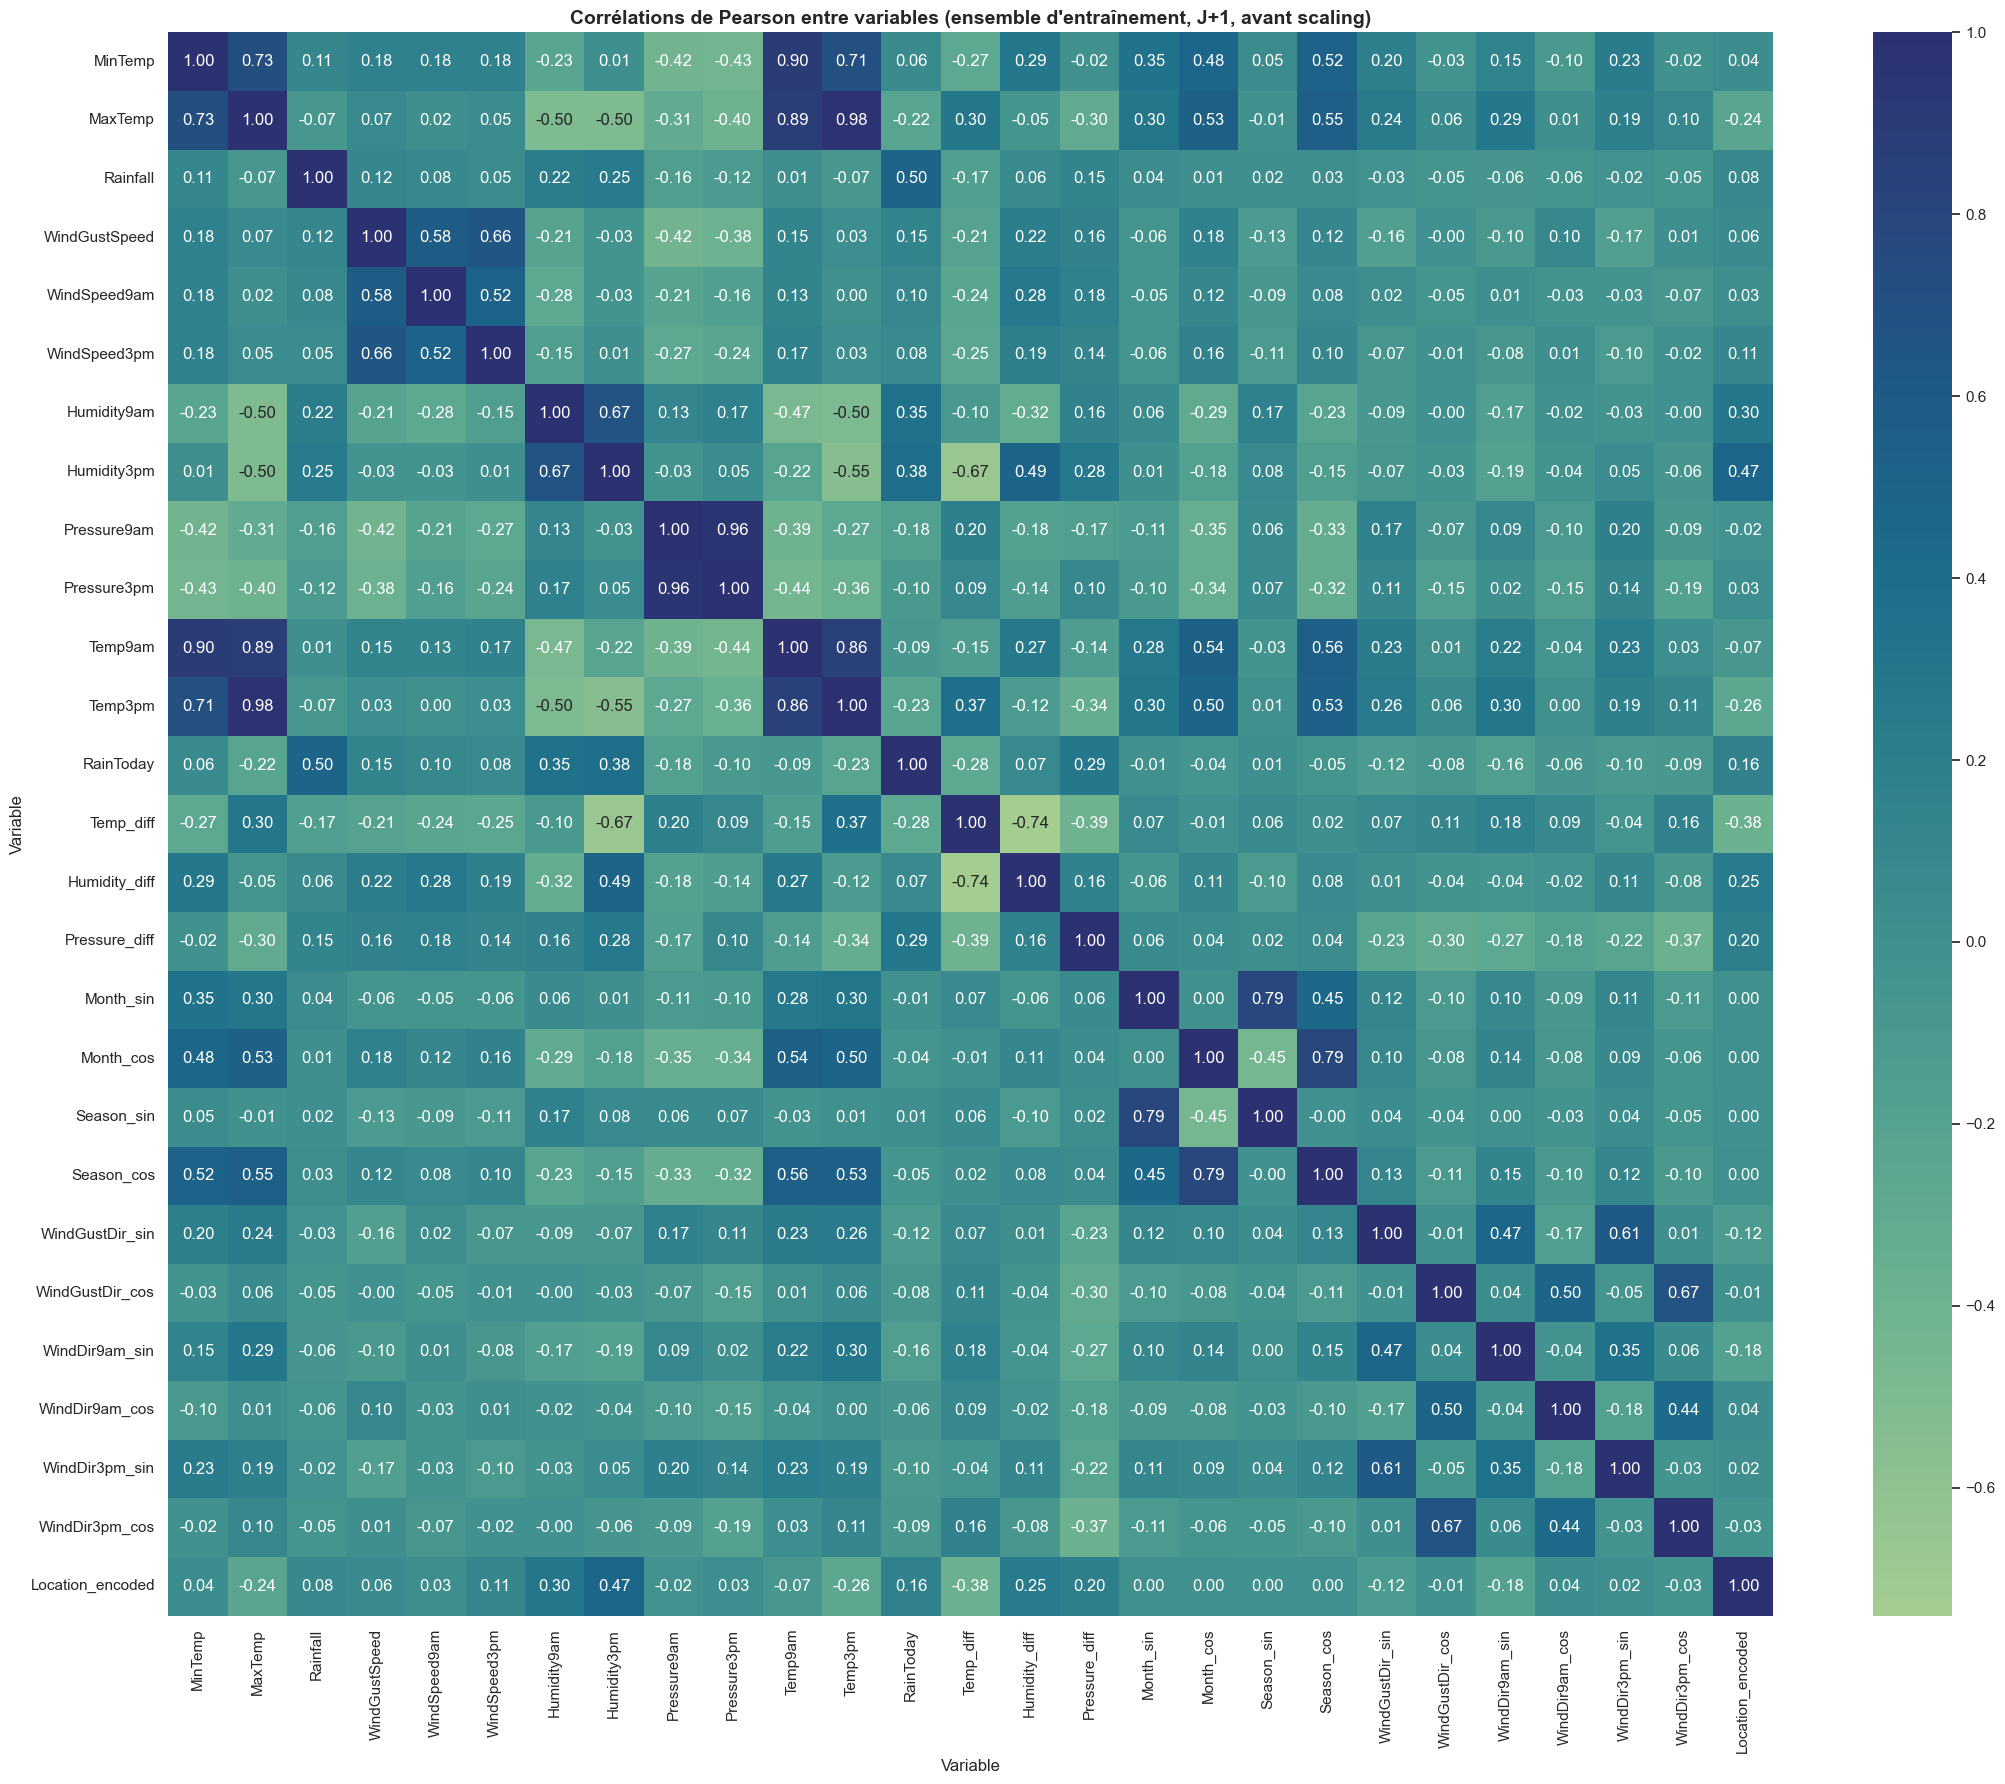

In [58]:
# CELL 58: Heatmap des corrélations entre variables (X_train, J+1)

plt.figure(figsize=(22, 18))
sns.heatmap(matrice_corr, annot=True, fmt='.2f', cmap='crest')
plt.title("Corrélations de Pearson entre variables (ensemble d'entraînement, J+1, avant scaling)",
          fontsize=14, fontweight='bold')
plt.xlabel("Variable")
plt.ylabel("Variable")
plt.tight_layout()
plt.savefig('../figures/etape2_10_correlations_variables.png', dpi=150)
print("\nFigure sauvegardée: figures/etape2_10_correlations_variables.png")
plt.show()

In [59]:
# CELL 59: Listes de colonnes des scalers pour la comparaison jeu complet / jeu réduit
# Règle de décision fixée avant la mesure : le jeu réduit est retenu si son F1 moyen (valeurs non arrondies) est supérieur ou égal à celui du jeu complet pour au moins 3 des 5 modèles ; sinon le jeu complet est conservé.
# Le jeu réduit de chaque pli = le jeu complet moins les variables retirées par le filtre recalculé sur la partie entraînement de ce pli.

from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler

# Listes de colonnes des 3 scalers : mêmes listes que le pipeline final (règle de CELL 74), sans Location_encoded_J2
# (RainToday n'est pas mis à l'échelle)
cols_standard = ['MinTemp', 'MaxTemp', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Temp9am', 'Temp3pm',
                 'Temp_diff', 'Location_encoded']
cols_robust = ['Rainfall', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am',
               'Humidity_diff', 'Pressure_diff']
cols_minmax = ['Month_sin', 'Month_cos', 'Season_sin', 'Season_cos', 'WindGustDir_sin', 'WindGustDir_cos',
               'WindDir9am_sin', 'WindDir9am_cos', 'WindDir3pm_sin', 'WindDir3pm_cos']

In [60]:
# CELL 60: Fonctions de préparation d'un pli (comparaison jeu complet / jeu réduit)

# Fonctions du pipeline final : imputation (CELL 22 et CELL 26), creer_variables et numero_saison (CELL 43),
# encode_cyclical, numero_direction et cols_directions (CELL 24), encoder_location (CELL 25)

def encoder_variables(X):
    # RainToday : No -> 0, Yes -> 1 ; Month : cycle de 12 ; Season : numéro 0 à 3, puis cycle de 4 ;
    # directions : numéro 0 à 15, puis cycle de 16
    X['RainToday'] = X['RainToday'].map({'No': 0, 'Yes': 1})
    encode_cyclical(X, 'Month', 12)
    X['Season'] = X['Season'].map(numero_saison)
    encode_cyclical(X, 'Season', 4)
    X['WindGustDir'] = X['WindGustDir'].map(numero_direction)
    encode_cyclical(X, 'WindGustDir', 16)
    X['WindDir9am'] = X['WindDir9am'].map(numero_direction)
    encode_cyclical(X, 'WindDir9am', 16)
    X['WindDir3pm'] = X['WindDir3pm'].map(numero_direction)
    encode_cyclical(X, 'WindDir3pm', 16)
    return X


def preparer_pli(X_tr, X_va, y_tr):
    # Toutes les statistiques sont calculées sur la partie entraînement du pli uniquement :
    # imputation locale, création des variables (Month, Season, 3 écarts), encodage
    X_tr, X_va = imputer_pli(X_tr, X_va, 'locale')
    X_tr = encoder_variables(creer_variables(X_tr))
    X_va = encoder_variables(creer_variables(X_va))
    X_tr, X_va = encoder_location(X_tr, X_va, y_tr)
    X_tr = X_tr.drop(columns=['Date', 'Location', 'Month', 'Season'] + cols_directions)
    X_va = X_va.drop(columns=['Date', 'Location', 'Month', 'Season'] + cols_directions)
    X_va = X_va[X_tr.columns]
    return X_tr, X_va

In [61]:
# CELL 61: Fonction de mise à l'échelle d'un pli

def colonnes_presentes(liste, X):
    # Colonnes de la liste encore présentes dans X (ordre de la liste conservé)
    cols = []
    for col in liste:
        if col in X.columns:
            cols.append(col)
    return cols


def mettre_a_l_echelle(X_tr, X_va):
    # Les 3 scalers du pipeline final, ajustés sur la partie entraînement du pli uniquement
    # (colonnes retirées exclues des listes)
    X_tr_s = X_tr.copy()
    X_va_s = X_va.copy()
    cols = colonnes_presentes(cols_standard, X_tr)
    scaler_s = StandardScaler()
    X_tr_s[cols] = scaler_s.fit_transform(X_tr[cols])
    X_va_s[cols] = scaler_s.transform(X_va[cols])
    cols = colonnes_presentes(cols_robust, X_tr)
    scaler_r = RobustScaler()
    X_tr_s[cols] = scaler_r.fit_transform(X_tr[cols])
    X_va_s[cols] = scaler_r.transform(X_va[cols])
    cols = colonnes_presentes(cols_minmax, X_tr)
    scaler_m = MinMaxScaler()
    X_tr_s[cols] = scaler_m.fit_transform(X_tr[cols])
    X_va_s[cols] = scaler_m.transform(X_va[cols])
    return X_tr_s, X_va_s

In [62]:
# CELL 62: Fonctions du filtre de redondance d'un pli

# Même règle qu'en CELL 56 et CELL 57, appliquée uniquement aux données reçues (partie entraînement d'un pli)

def paires_redondantes(X_tr):
    # Paires de variables avec |r| >= seuil_redondance, triées par |r| décroissant
    matrice = X_tr.corr(method='pearson')
    variables_1 = []
    variables_2 = []
    valeurs_abs_r = []
    for i in range(len(matrice.columns)):
        for j in range(i + 1, len(matrice.columns)):
            variables_1.append(matrice.columns[i])
            variables_2.append(matrice.columns[j])
            valeurs_abs_r.append(np.abs(matrice.iloc[i, j]))
    paires = pd.DataFrame({'Variable_1': variables_1, 'Variable_2': variables_2, 'abs_r': valeurs_abs_r})
    paires = paires[paires['abs_r'] >= seuil_redondance]
    return paires.sort_values('abs_r', ascending=False).reset_index().drop(columns=['index'])


def filtre_redondance(X_tr, y_tr_enc):
    # Pour chaque paire dont les deux variables sont encore conservées, on retire la moins corrélée à la cible
    corr_cible_pli = {}
    for col in X_tr.columns:
        corr_cible_pli[col] = np.abs(y_tr_enc.corr(X_tr[col]))
    paires = paires_redondantes(X_tr)
    retirees = []
    for i in range(len(paires)):
        v1 = paires.iloc[i]['Variable_1']
        v2 = paires.iloc[i]['Variable_2']
        if v1 in retirees or v2 in retirees:
            continue
        if corr_cible_pli[v1] >= corr_cible_pli[v2]:
            retirees.append(v2)
        else:
            retirees.append(v1)
    return retirees


print("Fonctions preparer_pli, mettre_a_l_echelle et filtre_redondance définies.")

Fonctions preparer_pli, mettre_a_l_echelle et filtre_redondance définies.


In [63]:
# CELL 63: Préparation des plis pour la comparaison jeu complet vs jeu réduit

# Jeux comparés : complet, et réduit (jeu complet moins les variables retirées par le filtre de redondance,
# recalculé sur la partie entraînement de chaque pli : la validation n'intervient jamais dans le filtre)
jeux = ['complet', 'reduit']

# Données de chaque pli préparées une seule fois, puis réutilisées par les 5 modèles
donnees_jeux = {'complet': [], 'reduit': []}
retirees_par_pli = []
for k in range(len(plis)):
    masque_tr = plis[k][0]
    masque_va = plis[k][1]
    y_tr = y_train_avant_imputation[masque_tr]
    y_va_enc = (y_train_avant_imputation[masque_va] == 'Yes').astype(int)
    y_tr_enc = (y_tr == 'Yes').astype(int)

    # Jeu complet, puis filtre de redondance recalculé sur la partie entraînement du pli uniquement
    X_tr_complet, X_va_complet = preparer_pli(X_train_avant_imputation[masque_tr], X_train_avant_imputation[masque_va], y_tr)
    retirees_pli = filtre_redondance(X_tr_complet, y_tr_enc)
    retirees_par_pli.append(retirees_pli)
    X_tr_reduit = X_tr_complet.drop(columns=retirees_pli)
    X_va_reduit = X_va_complet.drop(columns=retirees_pli)

    # Données mises à l'échelle pour la régression logistique, le KNN et le réseau de neurones
    X_tr_s, X_va_s = mettre_a_l_echelle(X_tr_complet, X_va_complet)
    donnees_jeux['complet'].append({'X_tr': X_tr_complet, 'X_va': X_va_complet, 'X_tr_s': X_tr_s, 'X_va_s': X_va_s,
                                    'y_tr_enc': y_tr_enc, 'y_va_enc': y_va_enc})
    X_tr_s, X_va_s = mettre_a_l_echelle(X_tr_reduit, X_va_reduit)
    donnees_jeux['reduit'].append({'X_tr': X_tr_reduit, 'X_va': X_va_reduit, 'X_tr_s': X_tr_s, 'X_va_s': X_va_s,
                                   'y_tr_enc': y_tr_enc, 'y_va_enc': y_va_enc})

In [64]:
# CELL 64: Jeu complet vs jeu réduit : régression logistique (données mises à l'échelle)

f1_lr_jeux = {'complet': [], 'reduit': []}
for k in range(len(plis)):
    # Jeu complet
    d = donnees_jeux['complet'][k]
    debut = time()
    lr = LogisticRegression(max_iter=1000)
    lr.fit(d['X_tr_s'], d['y_tr_enc'])
    duree_fit = time() - debut
    f1 = f1_score(d['y_va_enc'], lr.predict(d['X_va_s']))
    f1_lr_jeux['complet'].append(f1)
    print(f"Pli {k + 1} | complet | Regression logistique | entraînement {duree_fit:.2f} s | F1 = {f1:.4f}")
    # Jeu réduit
    d = donnees_jeux['reduit'][k]
    debut = time()
    lr = LogisticRegression(max_iter=1000)
    lr.fit(d['X_tr_s'], d['y_tr_enc'])
    duree_fit = time() - debut
    f1 = f1_score(d['y_va_enc'], lr.predict(d['X_va_s']))
    f1_lr_jeux['reduit'].append(f1)
    print(f"Pli {k + 1} | reduit | Regression logistique | entraînement {duree_fit:.2f} s | F1 = {f1:.4f}")

Pli 1 | complet | Regression logistique | entraînement 0.08 s | F1 = 0.5632
Pli 1 | reduit | Regression logistique | entraînement 0.08 s | F1 = 0.5668


Pli 2 | complet | Regression logistique | entraînement 0.13 s | F1 = 0.6065
Pli 2 | reduit | Regression logistique | entraînement 0.12 s | F1 = 0.6069


Pli 3 | complet | Regression logistique | entraînement 0.22 s | F1 = 0.5629
Pli 3 | reduit | Regression logistique | entraînement 0.17 s | F1 = 0.5639


Pli 4 | complet | Regression logistique | entraînement 0.26 s | F1 = 0.6013


Pli 4 | reduit | Regression logistique | entraînement 0.30 s | F1 = 0.6017


Pli 5 | complet | Regression logistique | entraînement 0.32 s | F1 = 0.5450


Pli 5 | reduit | Regression logistique | entraînement 0.46 s | F1 = 0.5452


In [65]:
# CELL 65: Jeu complet vs jeu réduit : Random Forest (données non mises à l'échelle)

f1_rf_jeux = {'complet': [], 'reduit': []}
for k in range(len(plis)):
    # Jeu complet
    d = donnees_jeux['complet'][k]
    debut = time()
    rf = RandomForestClassifier(random_state=42, n_jobs=-1)
    rf.fit(d['X_tr'], d['y_tr_enc'])
    duree_fit = time() - debut
    f1 = f1_score(d['y_va_enc'], rf.predict(d['X_va']))
    f1_rf_jeux['complet'].append(f1)
    print(f"Pli {k + 1} | complet | Random Forest | entraînement {duree_fit:.2f} s | F1 = {f1:.4f}")
    # Jeu réduit
    d = donnees_jeux['reduit'][k]
    debut = time()
    rf = RandomForestClassifier(random_state=42, n_jobs=-1)
    rf.fit(d['X_tr'], d['y_tr_enc'])
    duree_fit = time() - debut
    f1 = f1_score(d['y_va_enc'], rf.predict(d['X_va']))
    f1_rf_jeux['reduit'].append(f1)
    print(f"Pli {k + 1} | reduit | Random Forest | entraînement {duree_fit:.2f} s | F1 = {f1:.4f}")

Pli 1 | complet | Random Forest | entraînement 0.20 s | F1 = 0.5653


Pli 1 | reduit | Random Forest | entraînement 0.22 s | F1 = 0.5464


Pli 2 | complet | Random Forest | entraînement 0.64 s | F1 = 0.6101


Pli 2 | reduit | Random Forest | entraînement 0.59 s | F1 = 0.6115


Pli 3 | complet | Random Forest | entraînement 1.31 s | F1 = 0.5772


Pli 3 | reduit | Random Forest | entraînement 1.06 s | F1 = 0.5811


Pli 4 | complet | Random Forest | entraînement 1.91 s | F1 = 0.6137


Pli 4 | reduit | Random Forest | entraînement 1.60 s | F1 = 0.6177


Pli 5 | complet | Random Forest | entraînement 2.78 s | F1 = 0.5584


Pli 5 | reduit | Random Forest | entraînement 2.13 s | F1 = 0.5610


In [66]:
# CELL 66: Jeu complet vs jeu réduit : XGBoost (données non mises à l'échelle)

f1_xgb_jeux = {'complet': [], 'reduit': []}
for k in range(len(plis)):
    # Jeu complet
    d = donnees_jeux['complet'][k]
    debut = time()
    xgb = XGBClassifier(random_state=42, n_jobs=-1)
    xgb.fit(d['X_tr'], d['y_tr_enc'])
    duree_fit = time() - debut
    f1 = f1_score(d['y_va_enc'], xgb.predict(d['X_va']))
    f1_xgb_jeux['complet'].append(f1)
    print(f"Pli {k + 1} | complet | XGBoost | entraînement {duree_fit:.2f} s | F1 = {f1:.4f}")
    # Jeu réduit
    d = donnees_jeux['reduit'][k]
    debut = time()
    xgb = XGBClassifier(random_state=42, n_jobs=-1)
    xgb.fit(d['X_tr'], d['y_tr_enc'])
    duree_fit = time() - debut
    f1 = f1_score(d['y_va_enc'], xgb.predict(d['X_va']))
    f1_xgb_jeux['reduit'].append(f1)
    print(f"Pli {k + 1} | reduit | XGBoost | entraînement {duree_fit:.2f} s | F1 = {f1:.4f}")

Pli 1 | complet | XGBoost | entraînement 0.26 s | F1 = 0.5547


Pli 1 | reduit | XGBoost | entraînement 0.20 s | F1 = 0.5455


Pli 2 | complet | XGBoost | entraînement 0.31 s | F1 = 0.6342


Pli 2 | reduit | XGBoost | entraînement 0.28 s | F1 = 0.6357


Pli 3 | complet | XGBoost | entraînement 0.42 s | F1 = 0.6125


Pli 3 | reduit | XGBoost | entraînement 0.47 s | F1 = 0.6094


Pli 4 | complet | XGBoost | entraînement 0.55 s | F1 = 0.6410


Pli 4 | reduit | XGBoost | entraînement 0.55 s | F1 = 0.6431


Pli 5 | complet | XGBoost | entraînement 0.76 s | F1 = 0.5974


Pli 5 | reduit | XGBoost | entraînement 0.61 s | F1 = 0.6020


In [67]:
# CELL 67: Jeu complet vs jeu réduit : KNN (paramètres par défaut, données mises à l'échelle)

# Le KNN n'apprend rien à l'entraînement : le coût est dans la prédiction, on l'affiche aussi
f1_knn_jeux = {'complet': [], 'reduit': []}
for k in range(len(plis)):
    # Jeu complet
    d = donnees_jeux['complet'][k]
    debut = time()
    knn = KNeighborsClassifier(n_jobs=-1)
    knn.fit(d['X_tr_s'], d['y_tr_enc'])
    duree_fit = time() - debut
    debut = time()
    pred_knn = knn.predict(d['X_va_s'])
    duree_pred = time() - debut
    f1 = f1_score(d['y_va_enc'], pred_knn)
    f1_knn_jeux['complet'].append(f1)
    print(f"Pli {k + 1} | complet | KNN | entraînement {duree_fit:.2f} s "
          f"(prédiction {duree_pred:.2f} s) | F1 = {f1:.4f}")
    # Jeu réduit
    d = donnees_jeux['reduit'][k]
    debut = time()
    knn = KNeighborsClassifier(n_jobs=-1)
    knn.fit(d['X_tr_s'], d['y_tr_enc'])
    duree_fit = time() - debut
    debut = time()
    pred_knn = knn.predict(d['X_va_s'])
    duree_pred = time() - debut
    f1 = f1_score(d['y_va_enc'], pred_knn)
    f1_knn_jeux['reduit'].append(f1)
    print(f"Pli {k + 1} | reduit | KNN | entraînement {duree_fit:.2f} s "
          f"(prédiction {duree_pred:.2f} s) | F1 = {f1:.4f}")

Pli 1 | complet | KNN | entraînement 0.01 s (prédiction 0.12 s) | F1 = 0.4645


Pli 1 | reduit | KNN | entraînement 0.01 s (prédiction 0.11 s) | F1 = 0.4726


Pli 2 | complet | KNN | entraînement 0.02 s (prédiction 0.56 s) | F1 = 0.5584


Pli 2 | reduit | KNN | entraînement 0.02 s (prédiction 0.56 s) | F1 = 0.5649


Pli 3 | complet | KNN | entraînement 0.02 s (prédiction 0.97 s) | F1 = 0.5433


Pli 3 | reduit | KNN | entraînement 0.02 s (prédiction 0.89 s) | F1 = 0.5468


Pli 4 | complet | KNN | entraînement 0.04 s (prédiction 1.36 s) | F1 = 0.5754


Pli 4 | reduit | KNN | entraînement 0.04 s (prédiction 1.37 s) | F1 = 0.5803


Pli 5 | complet | KNN | entraînement 0.06 s (prédiction 1.76 s) | F1 = 0.5350


Pli 5 | reduit | KNN | entraînement 0.05 s (prédiction 1.82 s) | F1 = 0.5378


In [68]:
# CELL 68: Jeu complet vs jeu réduit : réseau de neurones (Keras, données mises à l'échelle)

# Même réseau qu'en CELL 32 (fonction entrainer_reseau)
f1_nn_jeux = {'complet': [], 'reduit': []}
for k in range(len(plis)):
    # Jeu complet
    d = donnees_jeux['complet'][k]
    pred_nn, duree_fit = entrainer_reseau(d['X_tr_s'].values, d['y_tr_enc'].values, d['X_va_s'].values)
    f1 = f1_score(d['y_va_enc'], pred_nn)
    f1_nn_jeux['complet'].append(f1)
    print(f"Pli {k + 1} | complet | Reseau de neurones | entraînement {duree_fit:.2f} s | F1 = {f1:.4f}")
    # Jeu réduit
    d = donnees_jeux['reduit'][k]
    pred_nn, duree_fit = entrainer_reseau(d['X_tr_s'].values, d['y_tr_enc'].values, d['X_va_s'].values)
    f1 = f1_score(d['y_va_enc'], pred_nn)
    f1_nn_jeux['reduit'].append(f1)
    print(f"Pli {k + 1} | reduit | Reseau de neurones | entraînement {duree_fit:.2f} s | F1 = {f1:.4f}")

Pli 1 | complet | Reseau de neurones | entraînement 3.47 s | F1 = 0.5867


Pli 1 | reduit | Reseau de neurones | entraînement 2.96 s | F1 = 0.5953


Pli 2 | complet | Reseau de neurones | entraînement 12.98 s | F1 = 0.6445


Pli 2 | reduit | Reseau de neurones | entraînement 13.32 s | F1 = 0.6388


Pli 3 | complet | Reseau de neurones | entraînement 23.76 s | F1 = 0.5913


Pli 3 | reduit | Reseau de neurones | entraînement 19.36 s | F1 = 0.5976


Pli 4 | complet | Reseau de neurones | entraînement 35.94 s | F1 = 0.6359


Pli 4 | reduit | Reseau de neurones | entraînement 25.54 s | F1 = 0.6227


Pli 5 | complet | Reseau de neurones | entraînement 36.53 s | F1 = 0.5898


Pli 5 | reduit | Reseau de neurones | entraînement 34.48 s | F1 = 0.5956


In [69]:
# CELL 69: Récapitulatif et application de la règle de décision (jeu complet vs jeu réduit)

# Règle de décision (fixée AVANT la mesure, voir CELL 59) : le jeu réduit est retenu si son F1 moyen
# (valeurs non arrondies) est supérieur ou égal à celui du jeu complet pour au moins 3 des 5 modèles

# Variables retirées par le filtre de redondance dans chaque pli
print("Variables retirées par le filtre de redondance (partie entraînement de chaque pli):")
for k in range(len(retirees_par_pli)):
    print(f"  Pli {k + 1}: {retirees_par_pli[k]}")
print()

# Listes de F1 déjà calculées en CELL 64 à CELL 68 (aucun réentraînement), dans l'ordre de modeles_5
f1_complet_par_modele = [f1_lr_jeux['complet'], f1_rf_jeux['complet'], f1_xgb_jeux['complet'], f1_knn_jeux['complet'], f1_nn_jeux['complet']]
f1_reduit_par_modele = [f1_lr_jeux['reduit'], f1_rf_jeux['reduit'], f1_xgb_jeux['reduit'], f1_knn_jeux['reduit'], f1_nn_jeux['reduit']]

nb_modeles_reduit = 0
for i in range(len(modeles_5)):
    f1_complet = f1_complet_par_modele[i]
    f1_reduit = f1_reduit_par_modele[i]
    print(f"===== {modeles_5[i]} =====")
    differences = []
    for k in range(len(f1_complet)):
        differences.append(f1_reduit[k] - f1_complet[k])
        print(f"  Pli {k + 1}: complet = {f1_complet[k]} | réduit = {f1_reduit[k]} | "
              f"réduit - complet = {differences[k]}")
    moyenne_complet = np.mean(f1_complet)
    moyenne_reduit = np.mean(f1_reduit)
    print(f"  F1 moyen complet: {moyenne_complet}")
    print(f"  F1 moyen réduit:  {moyenne_reduit}")
    print(f"  Différence moyenne (réduit - complet): {moyenne_reduit - moyenne_complet}")
    nb_plis_reduit = (np.array(differences) >= 0).sum()
    print(f"  Nombre de plis où réduit >= complet: {nb_plis_reduit} sur {len(differences)}\n")
    if moyenne_reduit >= moyenne_complet:
        nb_modeles_reduit += 1

print(f"Nombre de modèles où F1 moyen réduit >= F1 moyen complet: {nb_modeles_reduit} sur {len(modeles_5)}")

# Application de la règle de décision (au moins 3 modèles sur 5)
jeu_retenu = 'complet'
if nb_modeles_reduit >= 3:
    jeu_retenu = 'reduit'
print(f"Décision (règle : au moins 3 modèles sur 5) : jeu {jeu_retenu} retenu.")

Variables retirées par le filtre de redondance (partie entraînement de chaque pli):
  Pli 1: ['MaxTemp', 'Pressure3pm', 'Temp9am', 'Month_cos']
  Pli 2: ['MaxTemp', 'Pressure3pm', 'Temp9am']
  Pli 3: ['MaxTemp', 'Pressure3pm', 'Temp9am', 'Month_cos']
  Pli 4: ['MaxTemp', 'Pressure3pm', 'Temp9am']
  Pli 5: ['MaxTemp', 'Pressure3pm', 'Temp9am']

===== Regression logistique =====
  Pli 1: complet = 0.5632125665062072 | réduit = 0.5667934093789607 | réduit - complet = 0.003580842872753509
  Pli 2: complet = 0.606509197779471 | réduit = 0.6069445956242516 | réduit - complet = 0.00043539784478063837
  Pli 3: complet = 0.562863647862383 | réduit = 0.5639021930930174 | réduit - complet = 0.0010385452306344023
  Pli 4: complet = 0.6012832263978002 | réduit = 0.6017191977077364 | réduit - complet = 0.0004359713099362228
  Pli 5: complet = 0.5449960180514999 | réduit = 0.5451651412654198 | réduit - complet = 0.00016912321391993057
  F1 moyen complet: 0.5757729313194723
  F1 moyen réduit:  0.57690

Figure sauvegardée: figures/etape2_11_selection_variables.png


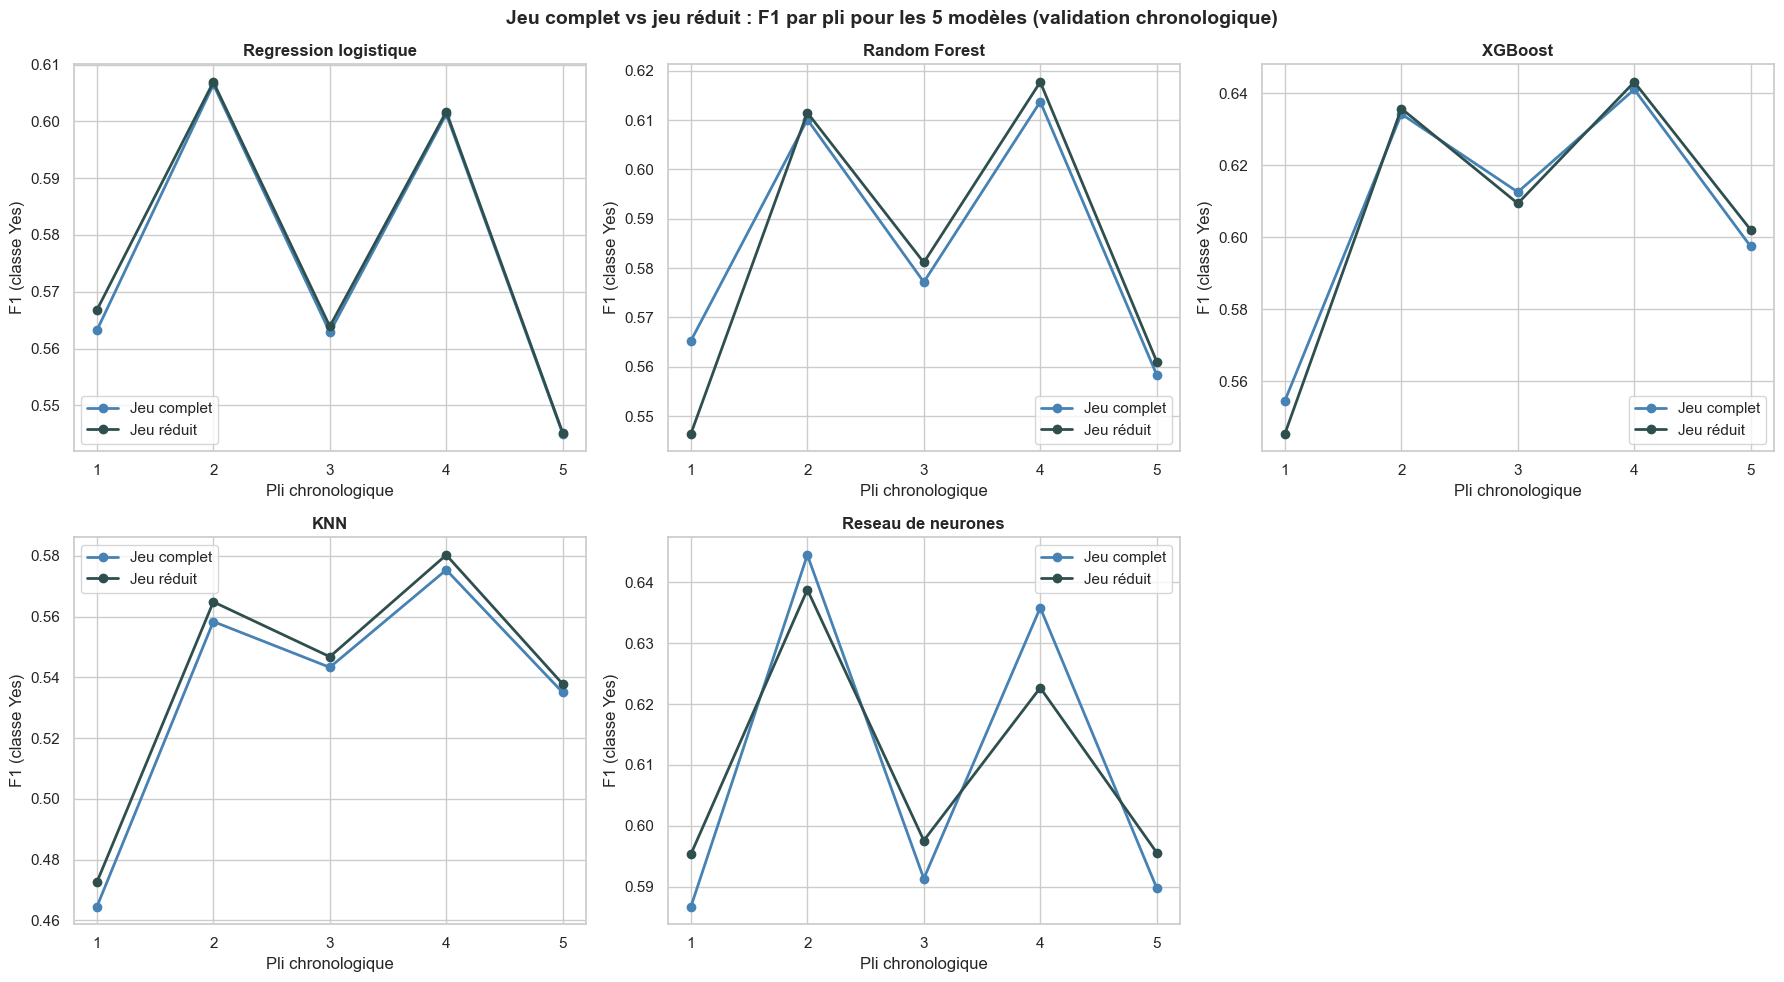

In [70]:
# CELL 70: Visualisation de la comparaison jeu complet vs jeu réduit (5 modèles)

numeros_plis = np.arange(1, len(plis) + 1)

# Une grille 2 x 3 : un sous-graphique par modèle
plt.figure(figsize=(18, 10))

for i in range(len(modeles_5)):
    plt.subplot(2, 3, i + 1)
    plt.plot(numeros_plis, f1_complet_par_modele[i], marker='o', linewidth=2, color='steelblue', label="Jeu complet")
    plt.plot(numeros_plis, f1_reduit_par_modele[i], marker='o', linewidth=2, color='darkslategray', label="Jeu réduit")
    plt.title(modeles_5[i], fontsize=12, fontweight='bold')
    plt.xlabel("Pli chronologique")
    plt.ylabel("F1 (classe Yes)")
    plt.xticks(numeros_plis)
    plt.legend()

plt.suptitle("Jeu complet vs jeu réduit : F1 par pli pour les 5 modèles (validation chronologique)",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/etape2_11_selection_variables.png', dpi=150)
print("Figure sauvegardée: figures/etape2_11_selection_variables.png")
plt.show()

In [71]:
# CELL 71: Application de la sélection de variables

# Jeu retenu : variable jeu_retenu, fixée par la règle de décision de la comparaison sur les 5 modèles (CELL 69).
# Variables retirées : celles du filtre de redondance de CELL 57 (variables_redondantes), calculé sur
# X_train entier (le jeu de test n'est jamais utilisé), seulement si le jeu réduit est retenu.
colonnes_retirees_selection = []
if jeu_retenu == 'reduit':
    colonnes_retirees_selection = variables_redondantes
print(f"Jeu retenu: {jeu_retenu}")

X_train = X_train.drop(columns=colonnes_retirees_selection)
X_test = X_test.drop(columns=colonnes_retirees_selection)

print(f"Colonnes retirées ({len(colonnes_retirees_selection)}): {colonnes_retirees_selection}")
print(f"\nColonnes restantes ({X_train.shape[1]}): {list(X_train.columns)}")
print(f"\nColonnes identiques entre X_train et X_test: {list(X_train.columns) == list(X_test.columns)}")
print(f"Dimensions X_train: {X_train.shape} | X_test: {X_test.shape}")

Jeu retenu: reduit
Colonnes retirées (3): ['MaxTemp', 'Pressure3pm', 'Temp9am']

Colonnes restantes (25): ['MinTemp', 'Rainfall', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Temp3pm', 'RainToday', 'Temp_diff', 'Humidity_diff', 'Pressure_diff', 'Month_sin', 'Month_cos', 'Season_sin', 'Season_cos', 'WindGustDir_sin', 'WindGustDir_cos', 'WindDir9am_sin', 'WindDir9am_cos', 'WindDir3pm_sin', 'WindDir3pm_cos', 'Location_encoded', 'Location_encoded_J2']

Colonnes identiques entre X_train et X_test: True
Dimensions X_train: (113748, 25) | X_test: (28445, 25)


In [72]:
# CELL 72: Choix du scaling : règle de décision et origine des pourcentages de valeurs aberrantes

# Règle de décision (fixée AVANT la mesure) :
# - valeurs aberrantes présentes = au moins 1% de valeurs aberrantes IQR (même méthode qu'en CELL 10)
#   -> RobustScaler
# - sinon, distribution quasi-normale = |skew| < 0.5 (même seuil que pour le choix médiane / moyenne)
#   -> StandardScaler
# - sinon -> MinMaxScaler
# - Exception : les 10 colonnes sin / cos (Month, Season, WindGustDir, WindDir9am, WindDir3pm)
#   -> MinMaxScaler (distribution en U non normale d'un sinus / cosinus, sans valeurs aberrantes)
# - Jarque-Bera (statistique et p-valeur) et QQ-plots (CELL 76) sont affichés en appui : ils ne décident pas
# - RainToday est binaire (0/1) : pas de scaling (un IQR nul rendrait RobustScaler indéfini,
#   et 0/1 est déjà sur l'échelle [0, 1])
# - Les arbres n'ont pas besoin de scaling, mais un seul jeu de données sert à tous les modèles

from scipy.stats import jarque_bera

# Directions d'origine : df n'a plus été modifié depuis CELL 7 et X_train garde l'index de df depuis CELL 7 :
# les valeurs d'origine de chaque ligne de X_train se lisent dans df à partir de cet index
df_origine = df.loc[X_train.index]

# Pourcentages de valeurs aberrantes des 12 variables mesurées : CELL 10 (table_iqr, réutilisée sans recalcul)
pct_outliers_mesures = {}
for i in range(len(table_iqr)):
    pct_outliers_mesures[table_iqr['Variable'].values[i]] = table_iqr['pct_outliers'].values[i]


def pct_outliers_iqr(valeurs):
    # Même définition qu'en CELL 10
    Q1 = valeurs.quantile(0.25)
    Q3 = valeurs.quantile(0.75)
    IQR = Q3 - Q1
    return ((valeurs < Q1 - 1.5 * IQR) | (valeurs > Q3 + 1.5 * IQR)).mean() * 100


# Toutes les colonnes sauf RainToday
colonnes_a_scaler = []
for col in X_train.columns:
    if col != 'RainToday':
        colonnes_a_scaler.append(col)

In [73]:
# CELL 73: Pourcentage de valeurs aberrantes de chaque colonne (valeurs réelles uniquement)

# Toujours sur des valeurs RÉELLES (mesurées à l'origine), jamais sur des valeurs imputées :
# - 12 variables mesurées : pourcentages de CELL 10
# - 3 écarts : pourcentages de CELL 16 (écarts mesurés, paires complètes)
# - Month_sin / Month_cos et Season_sin / Season_cos : toutes les lignes (Date n'est jamais manquante)
# - 6 colonnes de direction : lignes où la direction d'origine était présente avant imputation
# - Location_encoded / Location_encoded_J2 : toutes les lignes (Location n'est jamais manquante)
pct_outliers_par_col = {}
base_par_col = {}
for col in colonnes_a_scaler:
    valeurs = X_train[col]
    # Nom de la variable d'origine : partie avant le premier '_' (Month_sin -> Month)
    variable_origine = col.split('_')[0]
    if col in pct_outliers_mesures:
        pct_outliers_par_col[col] = pct_outliers_mesures[col]
        base_par_col[col] = 'CELL 10 (valeurs mesurées)'
    elif col in pct_outliers_ecarts_mesures:
        pct_outliers_par_col[col] = pct_outliers_ecarts_mesures[col]
        base_par_col[col] = 'CELL 16 (écarts mesurés, paires complètes)'
    elif variable_origine in ['Month', 'Season']:
        pct_outliers_par_col[col] = pct_outliers_iqr(valeurs)
        base_par_col[col] = 'toutes les lignes (Date jamais manquante)'
    elif variable_origine in cols_directions:
        masque_mesure = df_origine[variable_origine].isnull() == False
        pct_outliers_par_col[col] = pct_outliers_iqr(valeurs[masque_mesure])
        base_par_col[col] = f'lignes où {variable_origine} était mesurée'
    else:
        pct_outliers_par_col[col] = pct_outliers_iqr(valeurs)
        base_par_col[col] = 'toutes les lignes (Location jamais manquante)'

In [74]:
# CELL 74: Mesures et application de la règle de choix du scaler (X_train)

# La skewness est calculée sur toutes les lignes de X_train ; Jarque-Bera en appui uniquement
resultats_scaling = []
for col in colonnes_a_scaler:
    valeurs = X_train[col]
    skew = valeurs.skew()
    pct_outliers = pct_outliers_par_col[col]
    jb_stat, jb_p = jarque_bera(valeurs)
    # Application de la règle (cols_trigo : les 10 colonnes sin / cos, CELL 53)
    if col in cols_trigo:
        scaler_choisi = 'MinMaxScaler'
        motif = "distribution en U non normale d'un sinus / cosinus, sans valeurs aberrantes"
    elif pct_outliers >= 1:
        scaler_choisi = 'RobustScaler'
        motif = "au moins 1% de valeurs aberrantes"
    elif np.abs(skew) < 0.5:
        scaler_choisi = 'StandardScaler'
        motif = "quasi-normale (|skew| < 0.5), moins de 1% de valeurs aberrantes"
    else:
        scaler_choisi = 'MinMaxScaler'
        motif = "asymétrique (|skew| >= 0.5), moins de 1% de valeurs aberrantes"
    resultats_scaling.append({
        'Variable': col,
        'skewness': round(skew, 3),
        'pct_outliers_IQR': round(pct_outliers, 2),
        'base_outliers': base_par_col[col],
        'JB_statistique': round(jb_stat, 1),
        'JB_p_valeur': jb_p,
        'Scaler': scaler_choisi,
        'motif': motif
    })

In [75]:
# CELL 75: Tableau du choix du scaling et listes de colonnes par scaler

table_scaling = pd.DataFrame(resultats_scaling).sort_values(['Scaler', 'Variable']).reset_index().drop(columns=['index'])
print("Mesures pour le choix du scaling (X_train):")
print(table_scaling)

# Scaler de chaque colonne, puis listes de colonnes par scaler (ordre des colonnes de X_train conservé)
scaler_par_col = {}
for i in range(len(table_scaling)):
    scaler_par_col[table_scaling['Variable'].values[i]] = table_scaling['Scaler'].values[i]
cols_standard = []
cols_robust = []
cols_minmax = []
for c in colonnes_a_scaler:
    if scaler_par_col[c] == 'StandardScaler':
        cols_standard.append(c)
    elif scaler_par_col[c] == 'RobustScaler':
        cols_robust.append(c)
    elif scaler_par_col[c] == 'MinMaxScaler':
        cols_minmax.append(c)

print(f"\nStandardScaler ({len(cols_standard)}): {cols_standard}")
print(f"RobustScaler ({len(cols_robust)}): {cols_robust}")
print(f"MinMaxScaler ({len(cols_minmax)}): {cols_minmax}")
print("Non mise à l'échelle (1): ['RainToday']")

Mesures pour le choix du scaling (X_train):
               Variable  skewness  pct_outliers_IQR                                  base_outliers  JB_statistique    JB_p_valeur          Scaler  \
0             Month_cos     0.052              0.00      toutes les lignes (Date jamais manquante)         10557.1   0.000000e+00    MinMaxScaler   
1             Month_sin     0.056              0.00      toutes les lignes (Date jamais manquante)         10824.2   0.000000e+00    MinMaxScaler   
2            Season_cos     0.055              0.00      toutes les lignes (Date jamais manquante)          4431.3   0.000000e+00    MinMaxScaler   
3            Season_sin     0.009              0.00      toutes les lignes (Date jamais manquante)          5047.8   0.000000e+00    MinMaxScaler   
4        WindDir3pm_cos     0.111              0.00             lignes où WindDir3pm était mesurée         10532.8   0.000000e+00    MinMaxScaler   
5        WindDir3pm_sin    -0.000              0.00           

Figure sauvegardée: figures/etape2_09_qqplots_normalite.png


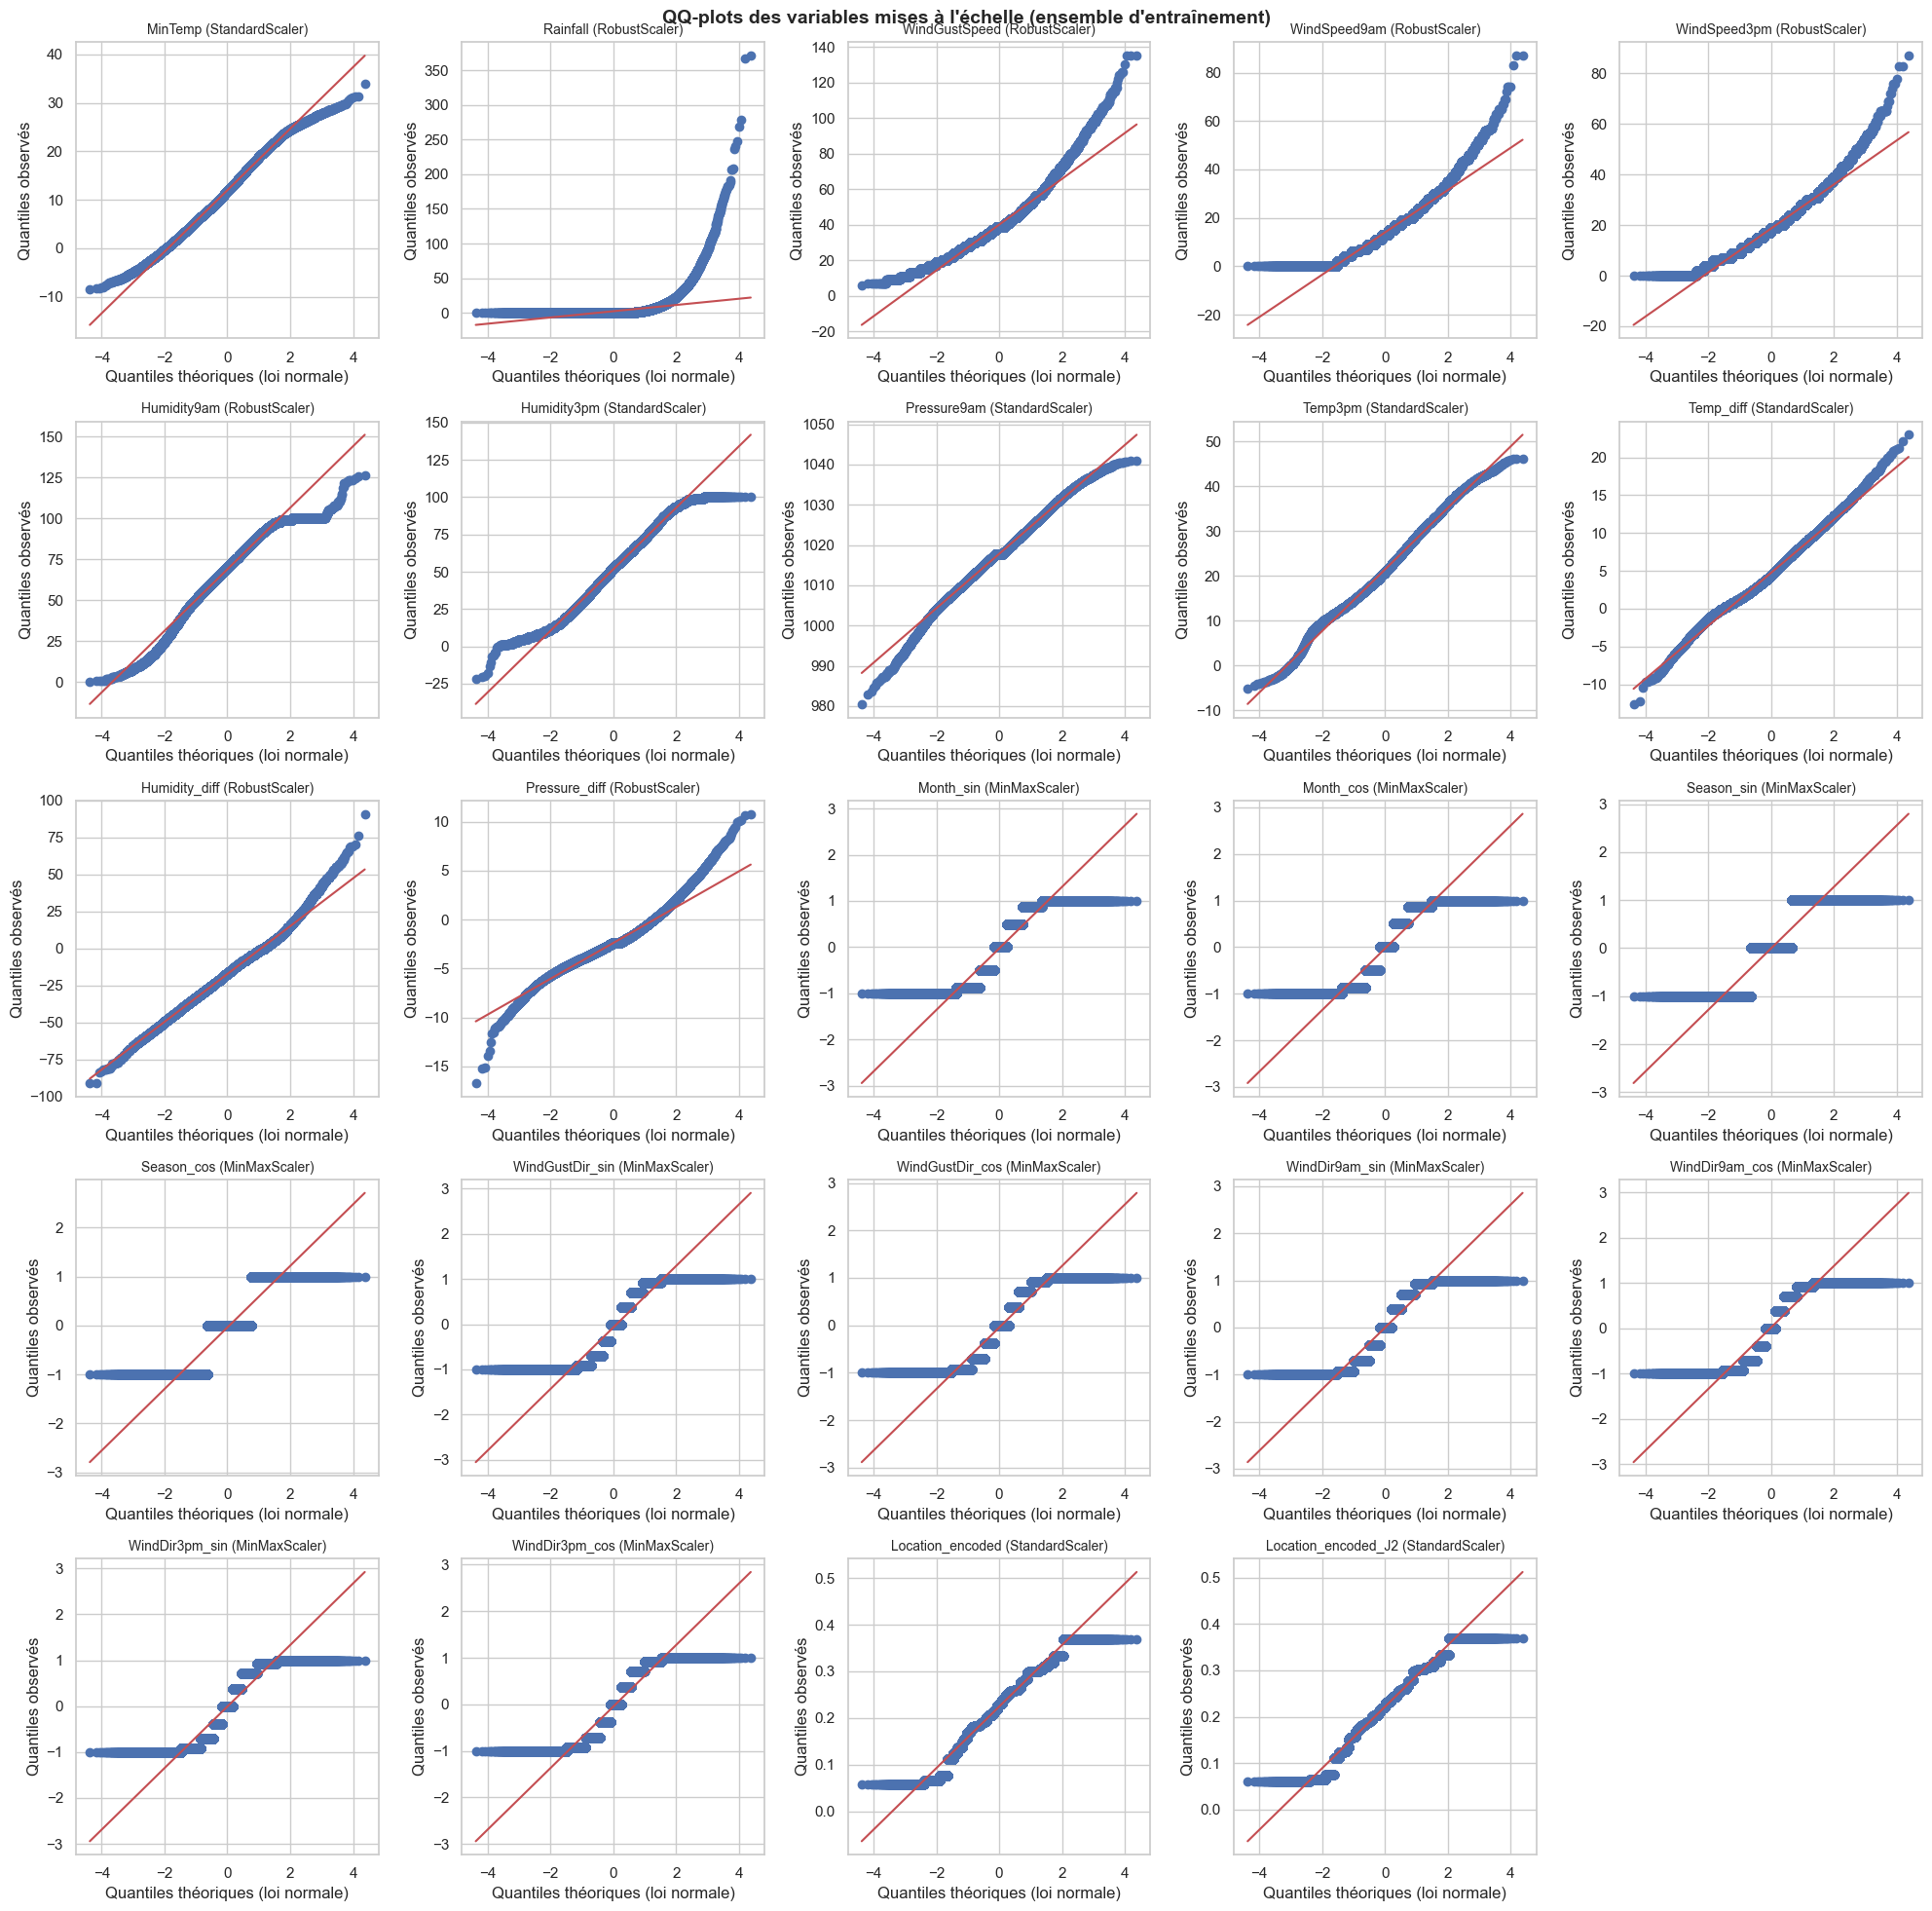

In [76]:
# CELL 76: QQ-plots des variables continues (X_train)

from scipy.stats import probplot

# Un sous-graphique par variable mise à l'échelle (scaler choisi en CELL 75)
n = len(colonnes_a_scaler)
n_cols = 5
# Nombre de lignes de la grille : division entière arrondie au supérieur
n_rows = (n + n_cols - 1) // n_cols

plt.figure(figsize=(20, 4 * n_rows))

for i in range(n):
    col = colonnes_a_scaler[i]
    plt.subplot(n_rows, n_cols, i + 1)
    probplot(X_train[col], dist='norm', plot=plt)
    plt.title(f"{col} ({scaler_par_col[col]})", fontsize=10)
    plt.xlabel("Quantiles théoriques (loi normale)")
    plt.ylabel("Quantiles observés")

plt.suptitle("QQ-plots des variables mises à l'échelle (ensemble d'entraînement)",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/etape2_09_qqplots_normalite.png', dpi=150)
print("Figure sauvegardée: figures/etape2_09_qqplots_normalite.png")
plt.show()

In [77]:
# CELL 77: Application du scaling (ajusté sur X_train uniquement)

# Copie non mise à l'échelle pour Random Forest et XGBoost (mêmes colonnes, avant scaling) :
# les modèles à base d'arbres n'ont pas besoin de scaling
X_train_arbres = X_train.copy()
X_test_arbres = X_test.copy()
print(f"Copies non mises à l'échelle: X_train_arbres {X_train_arbres.shape} | X_test_arbres {X_test_arbres.shape}\n")

# Un scaler par groupe de colonnes (règle de CELL 74), ajusté sur X_train uniquement,
# puis appliqué à X_train et X_test. RainToday n'est pas modifié.
# Conservés pour Streamlit : les 3 scalers et leurs listes de colonnes
scaler_standard = StandardScaler()
X_train[cols_standard] = scaler_standard.fit_transform(X_train[cols_standard])
X_test[cols_standard] = scaler_standard.transform(X_test[cols_standard])

scaler_robust = RobustScaler()
X_train[cols_robust] = scaler_robust.fit_transform(X_train[cols_robust])
X_test[cols_robust] = scaler_robust.transform(X_test[cols_robust])

scaler_minmax = MinMaxScaler()
X_train[cols_minmax] = scaler_minmax.fit_transform(X_train[cols_minmax])
X_test[cols_minmax] = scaler_minmax.transform(X_test[cols_minmax])

Copies non mises à l'échelle: X_train_arbres (113748, 25) | X_test_arbres (28445, 25)



In [78]:
# CELL 78: Statistiques des colonnes après scaling

# Scaler de chaque colonne (aucun pour RainToday)
scalers_colonnes = []
for c in X_train.columns:
    if c in scaler_par_col:
        scalers_colonnes.append(scaler_par_col[c])
    else:
        scalers_colonnes.append('aucun')


def resume_apres_scaling(X):
    # Statistiques de chaque colonne après scaling, arrondies à 3 décimales
    minimums = []
    maximums = []
    moyennes = []
    ecarts_types = []
    for v in X.min().values:
        minimums.append(round(v, 3))
    for v in X.max().values:
        maximums.append(round(v, 3))
    for v in X.mean().values:
        moyennes.append(round(v, 3))
    for v in X.std().values:
        ecarts_types.append(round(v, 3))
    return pd.DataFrame({'Scaler': scalers_colonnes, 'min': minimums, 'max': maximums,
                         'moyenne': moyennes, 'ecart_type': ecarts_types}, index=X.columns)


print("X_train après scaling:")
print(resume_apres_scaling(X_train))
print(f"Valeurs manquantes restantes dans X_train: {int(X_train.isnull().sum().sum())}\n")
print("X_test après scaling:")
print(resume_apres_scaling(X_test))
print(f"Valeurs manquantes restantes dans X_test: {int(X_test.isnull().sum().sum())}\n")

X_train après scaling:
                             Scaler    min      max  moyenne  ecart_type
MinTemp              StandardScaler -3.214    3.449    0.000       1.000
Rainfall               RobustScaler  0.000  618.333    3.871      14.088
WindGustSpeed          RobustScaler -2.200    6.400    0.068       0.878
WindSpeed9am           RobustScaler -1.083    6.167    0.084       0.744
WindSpeed3pm           RobustScaler -1.727    6.182   -0.032       0.802
Humidity9am            RobustScaler -2.692    2.169   -0.042       0.731
Humidity3pm          StandardScaler -3.547    2.339    0.000       1.000
Pressure9am          StandardScaler -5.496    3.419   -0.000       1.000
Temp3pm              StandardScaler -3.857    3.576   -0.000       1.000
RainToday                     aucun  0.000    1.000    0.221       0.415
Temp_diff            StandardScaler -4.924    5.186    0.000       1.000
Humidity_diff          RobustScaler -3.364    4.909   -0.014       0.736
Pressure_diff          Robus

In [79]:
# CELL 79: Colonnes et lignes des jeux J+1 et J+2

dossier_sortie = '../data/output'

# Colonnes des deux jeux : J+1 sans Location_encoded_J2, J+2 sans Location_encoded
colonnes_J1 = []
colonnes_J2 = []
for col in X_train.columns:
    if col != 'Location_encoded_J2':
        colonnes_J1.append(col)
    if col != 'Location_encoded':
        colonnes_J2.append(col)

# Lignes J+2 : RainInTwoDays non manquant, séparément en entraînement et en test
masque_J2_train = y2_train_enc.isnull() == False
masque_J2_test = y2_test_enc.isnull() == False

In [80]:
# CELL 80: Jeux de données à sauvegarder (nom de fichier -> données)

jeux_sauvegardes = {
    # J+1
    'X_train_J1_scaled.csv': X_train[colonnes_J1],
    'X_test_J1_scaled.csv': X_test[colonnes_J1],
    'X_train_J1_arbres.csv': X_train_arbres[colonnes_J1],
    'X_test_J1_arbres.csv': X_test_arbres[colonnes_J1],
    'y_train_J1.csv': y_train_enc.to_frame('RainTomorrow'),
    'y_test_J1.csv': y_test_enc.to_frame('RainTomorrow'),
    'meta_train_J1.csv': meta_train[['Location', 'Date']],
    'meta_test_J1.csv': meta_test[['Location', 'Date']],
    # J+2
    'X_train_J2_scaled.csv': X_train.loc[masque_J2_train, colonnes_J2],
    'X_test_J2_scaled.csv': X_test.loc[masque_J2_test, colonnes_J2],
    'X_train_J2_arbres.csv': X_train_arbres.loc[masque_J2_train, colonnes_J2],
    'X_test_J2_arbres.csv': X_test_arbres.loc[masque_J2_test, colonnes_J2],
    'y_train_J2.csv': y2_train_enc[masque_J2_train].astype(int).to_frame('RainInTwoDays'),
    'y_test_J2.csv': y2_test_enc[masque_J2_test].astype(int).to_frame('RainInTwoDays'),
    'meta_train_J2.csv': meta_train.loc[masque_J2_train, ['Location', 'Date']],
    'meta_test_J2.csv': meta_test.loc[masque_J2_test, ['Location', 'Date']]
}

In [81]:
# CELL 81: Sauvegarde des jeux de données en CSV (sans index)

print("\nFichiers CSV écrits dans data/output/:")
for nom in jeux_sauvegardes:
    donnees = jeux_sauvegardes[nom]
    donnees.to_csv(dossier_sortie + '/' + nom, index=False)
    print(f"  {nom} {donnees.shape[0]} lignes x {donnees.shape[1]} colonnes")


Fichiers CSV écrits dans data/output/:


  X_train_J1_scaled.csv 113748 lignes x 24 colonnes


  X_test_J1_scaled.csv 28445 lignes x 24 colonnes


  X_train_J1_arbres.csv 113748 lignes x 24 colonnes


  X_test_J1_arbres.csv 28445 lignes x 24 colonnes
  y_train_J1.csv 113748 lignes x 1 colonnes
  y_test_J1.csv 28445 lignes x 1 colonnes
  meta_train_J1.csv 113748 lignes x 2 colonnes
  meta_test_J1.csv 28445 lignes x 2 colonnes


  X_train_J2_scaled.csv 112353 lignes x 24 colonnes


  X_test_J2_scaled.csv 28078 lignes x 24 colonnes


  X_train_J2_arbres.csv 112353 lignes x 24 colonnes


  X_test_J2_arbres.csv 28078 lignes x 24 colonnes
  y_train_J2.csv 112353 lignes x 1 colonnes
  y_test_J2.csv 28078 lignes x 1 colonnes
  meta_train_J2.csv 112353 lignes x 2 colonnes
  meta_test_J2.csv 28078 lignes x 2 colonnes


In [82]:
# CELL 82: Sauvegarde des transformations ajustées sur X_train (un seul dictionnaire, joblib)

import joblib

artefacts = {
    'colonnes_supprimees_manquants': colonnes_a_supprimer,
    'colonnes_retirees_selection': colonnes_retirees_selection,
    'paires_9h_15h': paires_diff,
    'colonnes_directions': cols_directions,
    'impute_local': impute_local,
    'impute_global': impute_global,
    'ecarts_types_local': ecarts_types_local,
    'ecarts_types_global': ecarts_types_global,
    'numero_direction': numero_direction,
    'numero_saison': numero_saison,
    'loc_rate_J1': loc_rate_J1,
    'loc_rate_J2': loc_rate_J2,
    'taux_global_J1': taux_global_J1,
    'taux_global_J2': taux_global_J2,
    'scalers': {'StandardScaler': scaler_standard, 'RobustScaler': scaler_robust, 'MinMaxScaler': scaler_minmax},
    'colonnes_scalers': {'StandardScaler': cols_standard, 'RobustScaler': cols_robust, 'MinMaxScaler': cols_minmax},
    'ordre_colonnes_avant_scaling': list(X_train_arbres.columns),
    'colonnes_J1': colonnes_J1,
    'colonnes_J2': colonnes_J2,
    'date_coupure': date_coupure
}
joblib.dump(artefacts, '../models/preprocessing_artifacts.joblib')
print("\nFichier sauvegardé : models/preprocessing_artifacts.joblib")
print(f"Clés: {list(artefacts.keys())}")


Fichier sauvegardé : models/preprocessing_artifacts.joblib
Clés: ['colonnes_supprimees_manquants', 'colonnes_retirees_selection', 'paires_9h_15h', 'colonnes_directions', 'impute_local', 'impute_global', 'ecarts_types_local', 'ecarts_types_global', 'numero_direction', 'numero_saison', 'loc_rate_J1', 'loc_rate_J2', 'taux_global_J1', 'taux_global_J2', 'scalers', 'colonnes_scalers', 'ordre_colonnes_avant_scaling', 'colonnes_J1', 'colonnes_J2', 'date_coupure']
